In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.interpolate import griddata
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
print(np.__version__)
print(pd.__version__)

1.26.4
2.3.2


In [2]:
df = pd.read_csv('JUIndoorLoc-Training-data.csv')
df_test = pd.read_csv('JUIndoorLoc-Test-data.csv')
df.shape, df_test.shape

((23904, 177), (1460, 177))

In [3]:
split_cols = df['Cid'].str.lstrip('L').str.split('-', expand=True)
split_cols.head(3)

,0,1,2
0,4,40,1
1,4,40,1
2,4,40,1


In [4]:
# Step 2: Assign new columns
df['floor'] = split_cols[0].astype(int)  # floor as integer
df['X'] = split_cols[1].astype(int)      # X coordinate
df['Y'] = split_cols[2].astype(int)      # Y coordinate

In [5]:
split_cols = df_test['Cid'].str.lstrip('L').str.split('-', expand=True)

# Step 2: Assign new columns
df_test['floor'] = split_cols[0].astype(int)  # floor as integer
df_test['X'] = split_cols[1].astype(int)      # X coordinate
df_test['Y'] = split_cols[2].astype(int)      # Y coordinate

In [6]:
df['floor'].value_counts()

floor
4    18016
5     4300
3     1588
Name: count, dtype: int64

In [7]:
df_test['floor'].value_counts()

floor
4    1460
Name: count, dtype: int64

In [8]:
df_3rd_floor = df[df['floor'] == 3]
df_4th_floor = df[df['floor'] == 4]
df_5th_floor = df[df['floor'] == 5]

In [9]:
def plot_floor_data(floor_df, label):
    fig, ax = plt.subplots()
    ax.scatter(floor_df['X'], floor_df['Y'])
    ax.set_xlabel('X(m)')
    ax.set_ylabel('Y(m)')
    ax.set_title(label)
    plt.show()

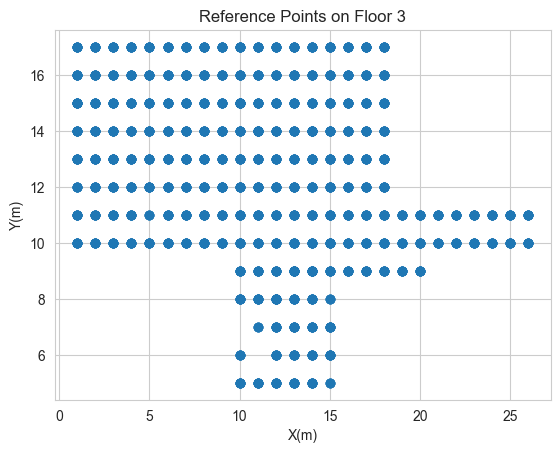

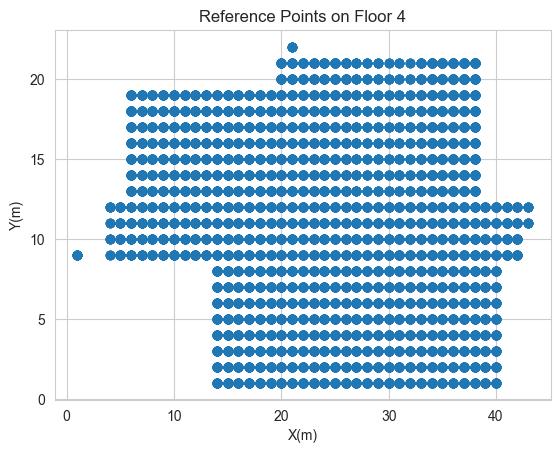

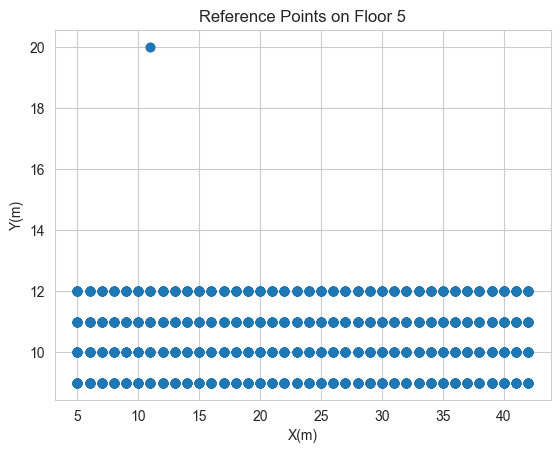

In [10]:
plot_floor_data(df_3rd_floor, "Reference Points on Floor 3")
plot_floor_data(df_4th_floor, "Reference Points on Floor 4")
plot_floor_data(df_5th_floor, "Reference Points on Floor 5")

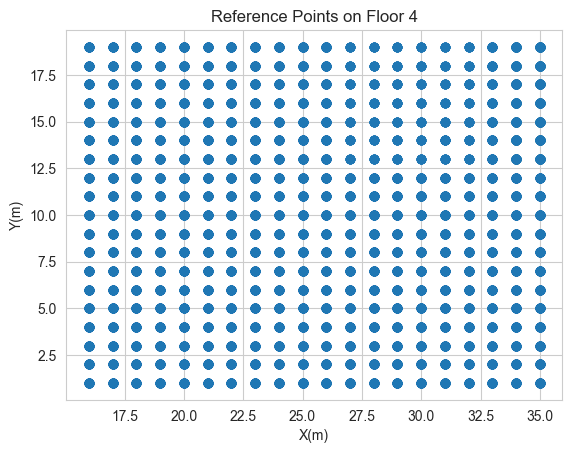

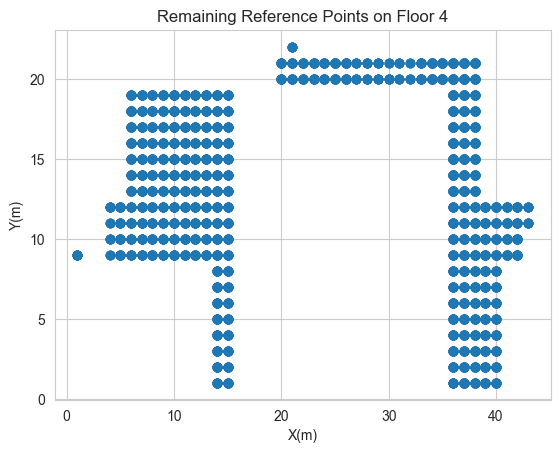

In [11]:
square_df = df_4th_floor[
    (df_4th_floor['X'] >= 16) & (df_4th_floor['X'] <= 35) & (df_4th_floor['Y'] >= 0) & (df_4th_floor['Y'] <= 19)]
remaining_df = df_4th_floor[
    ~((df_4th_floor['X'] >= 16) & (df_4th_floor['X'] <= 35) & (df_4th_floor['Y'] >= 0) & (df_4th_floor['Y'] <= 19))]
plot_floor_data(square_df, "Reference Points on Floor 4")
plot_floor_data(remaining_df, "Remaining Reference Points on Floor 4")


In [12]:
square_df.head(3)

,Cid,AP001,AP002,AP003,AP004,AP005,AP006,AP007,AP008,AP009,...,AP170,AP171,AP172,Rs,Hpr,Did,Ts,floor,X,Y
256,L4-34-1,-80,-81,-70,-63,-85,-75,-69,-110,-110,...,-110,-110,-110,0,0,D4,1469963153060,4,34,1
257,L4-34-1,-80,-81,-70,-63,-85,-75,-69,-110,-110,...,-110,-110,-110,0,0,D4,1470139819109,4,34,1
258,L4-34-1,-80,-80,-70,-63,-85,-75,-69,-110,-110,...,-110,-110,-110,0,0,D4,1469962304939,4,34,1


## Null values analysis:

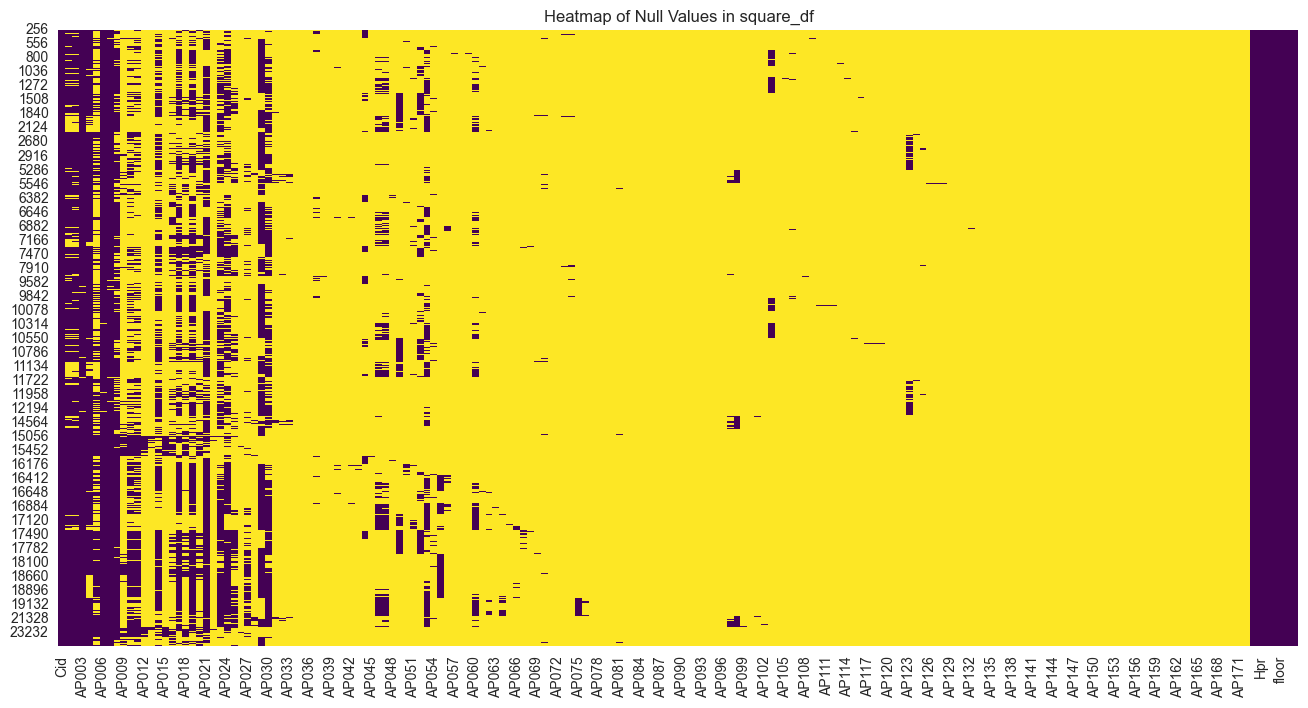

In [13]:
square_df = square_df.replace(-110, np.nan)
plt.figure(figsize=(16, 8))
sns.heatmap(square_df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Null Values in square_df')
plt.show()

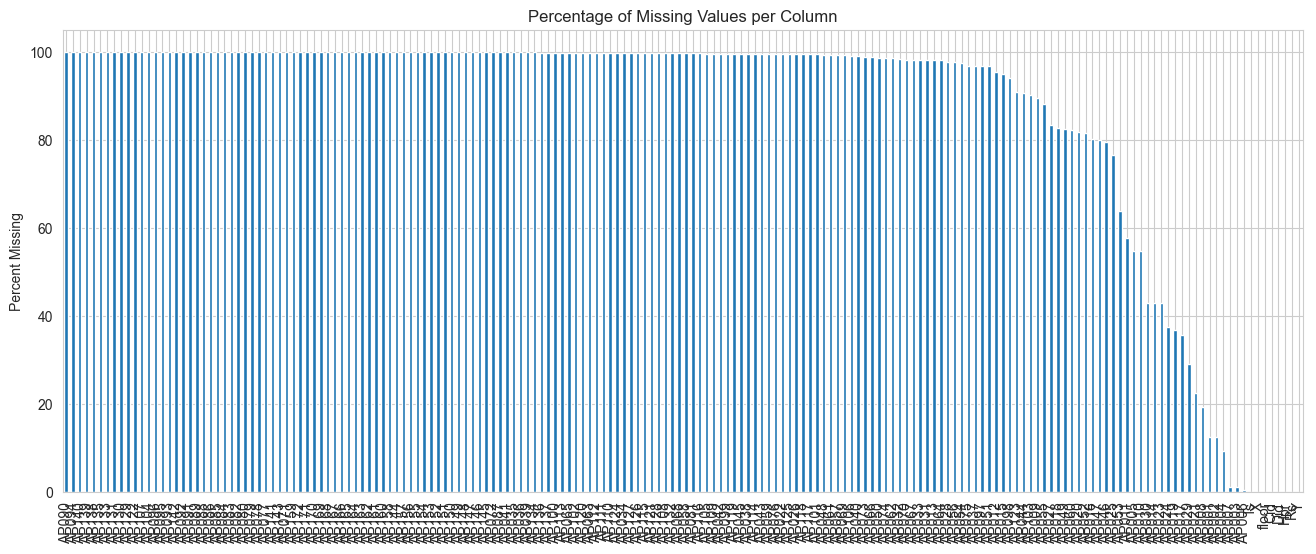

In [14]:
(square_df.isna().sum().sort_values(ascending=False) / len(square_df) * 100).plot(kind='bar', figsize=(16, 6), ylabel='Percent Missing')
plt.title('Percentage of Missing Values per Column')
plt.show()

In [15]:
print(f"Initial shape of the Dataset: {square_df.shape}")

Initial shape of the Dataset: (10379, 180)


In [16]:
null_percent = square_df.isna().sum() / len(square_df) * 100
cols_to_drop = null_percent[null_percent > 80].index
square_df_cleaned = square_df.drop(columns=cols_to_drop)
print(square_df_cleaned.info())

#-------------

null_percent_remaining_df = remaining_df.isna().sum() / len(remaining_df) * 100
cols_to_drop_remaining_df = null_percent_remaining_df[null_percent_remaining_df > 80].index
remaining_df_cleaned = remaining_df.drop(columns=cols_to_drop_remaining_df)
print(remaining_df_cleaned.info())

<class 'pandas.core.frame.DataFrame'>
Index: 10379 entries, 256 to 23847
Data columns (total 29 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Cid     10379 non-null  object 
 1   AP001   9065 non-null   float64
 2   AP002   9069 non-null   float64
 3   AP003   10263 non-null  float64
 4   AP004   9391 non-null   float64
 5   AP005   4690 non-null   float64
 6   AP006   10331 non-null  float64
 7   AP007   10257 non-null  float64
 8   AP008   8357 non-null   float64
 9   AP010   4696 non-null   float64
 10  AP011   4383 non-null   float64
 11  AP014   5904 non-null   float64
 12  AP017   6675 non-null   float64
 13  AP019   6559 non-null   float64
 14  AP021   8028 non-null   float64
 15  AP023   5909 non-null   float64
 16  AP024   6486 non-null   float64
 17  AP025   2429 non-null   float64
 18  AP029   7359 non-null   float64
 19  AP030   5903 non-null   float64
 20  AP046   2114 non-null   float64
 21  AP053   3747 non-null   float64
 22  R

In [17]:
print(f"Dataset after dropping columns: {square_df_cleaned.shape}")
print(f"Remaining dataset after dropping columns: {remaining_df_cleaned.shape}")

Dataset after dropping columns: (10379, 29)
Remaining dataset after dropping columns: (7637, 180)


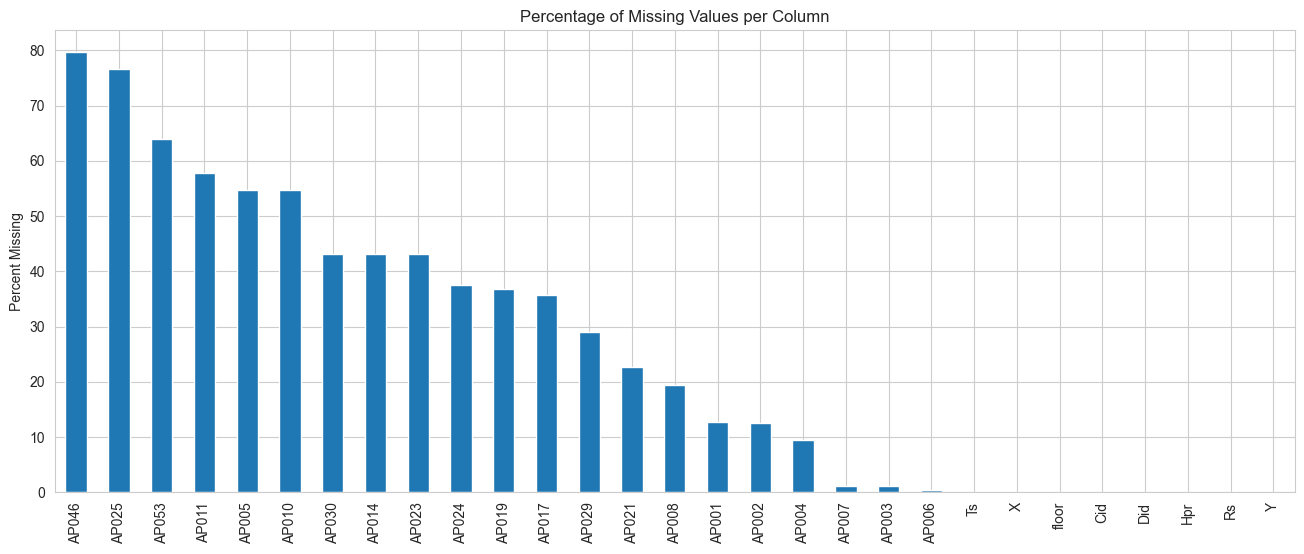

In [18]:
(square_df_cleaned.isna().sum().sort_values(ascending=False) / len(square_df_cleaned) * 100).plot(kind='bar', figsize=(16, 6), ylabel='Percent Missing')
plt.title('Percentage of Missing Values per Column')
plt.show()

In [19]:
# Feature Columns after cleaning

def get_ap_columns(dataset):
    return [col for col in dataset.columns if col.startswith('AP')]
ap_cols = get_ap_columns(square_df_cleaned)
print(len(ap_cols))
print(ap_cols)

21
['AP001', 'AP002', 'AP003', 'AP004', 'AP005', 'AP006', 'AP007', 'AP008', 'AP010', 'AP011', 'AP014', 'AP017', 'AP019', 'AP021', 'AP023', 'AP024', 'AP025', 'AP029', 'AP030', 'AP046', 'AP053']


In [20]:
cond_cols = ['X','Y']

In [21]:
null_stats_ap_by_did = square_df_cleaned.groupby('Did')[ap_cols].apply(lambda group: group.isna().mean().mean() * 100)
print("Null Stats by Did:")
print(null_stats_ap_by_did)

Null Stats by Did:
Did
D1    39.206770
D2    23.799705
D3    40.755841
D4    40.916272
dtype: float64


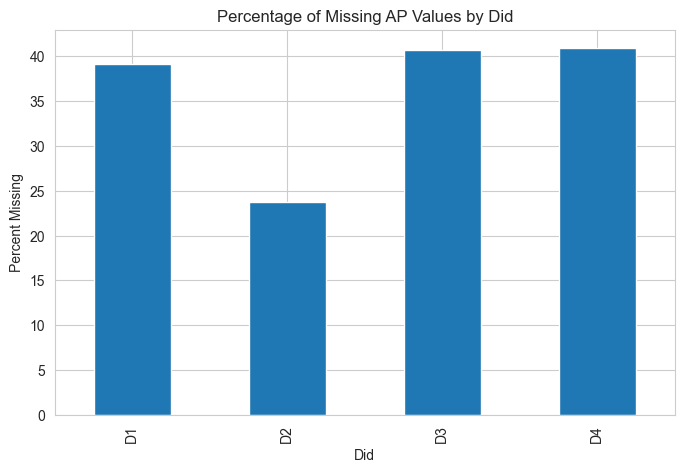

In [22]:
null_stats_ap_by_did.plot(kind='bar', figsize=(8, 5), ylabel='Percent Missing')
plt.title('Percentage of Missing AP Values by Did')
plt.show()

In [23]:
null_stats_ap_by_hpr = square_df_cleaned.groupby('Hpr')[ap_cols].apply(lambda group: group.isna().mean().mean() * 100)
print("Null Stats by Hpr:")
print(null_stats_ap_by_hpr)

Null Stats by Hpr:
Hpr
0    36.909046
1    33.898392
dtype: float64


In [24]:
null_stats_ap_by_rs = square_df_cleaned.groupby('Rs')[ap_cols].apply(lambda group: group.isna().mean().mean() * 100)
print("Null Stats by Rs:")
print(null_stats_ap_by_rs)

Null Stats by Rs:
Rs
0    36.104471
1    34.333220
dtype: float64


## Aggregation by mean

In [25]:
ap_mean_by_xy = square_df_cleaned.groupby(['X', 'Y'])[ap_cols].mean().reset_index()
print(ap_mean_by_xy.shape)
ap_mean_by_xy.head()

(380, 23)


,X,Y,AP001,AP002,AP003,AP004,AP005,AP006,AP007,AP008,...,AP017,AP019,AP021,AP023,AP024,AP025,AP029,AP030,AP046,AP053
0,16,1,-96.625,-87.5,-73.900000,NaN,NaN,-73.266667,-73.400000,-64.400000,...,NaN,NaN,-79.933333,-78.400000,NaN,NaN,-84.0,-78.800000,-81.000000,-76.066667
1,16,2,NaN,NaN,-65.892857,NaN,NaN,-63.821429,-63.500000,-63.285714,...,NaN,NaN,-73.928571,-73.142857,NaN,NaN,-90.0,-73.000000,-76.285714,-71.857143
2,16,3,NaN,NaN,-66.750000,NaN,NaN,-64.821429,-65.357143,-58.714286,...,-95.0,-96.0,-71.642857,-72.857143,-89.00,-96.0,-87.0,-73.642857,-75.571429,-72.285714
3,16,4,NaN,NaN,-60.857143,-96.5,NaN,-63.208333,-62.500000,-53.428571,...,-97.0,NaN,-71.230769,-73.857143,-89.25,-97.0,-90.0,-73.785714,-71.692308,-70.285714
4,16,5,-96.000,-91.5,-60.107143,-97.0,NaN,-59.392857,-57.857143,-57.642857,...,-95.0,-94.0,-68.000000,-76.928571,-96.00,-96.0,-83.0,-77.071429,-76.785714,-68.714286


## Heatmap plot

In [26]:
def plot_heatmap(dataset, feature):
    # Define grid
    xi = np.linspace(dataset['X'].min(), dataset['X'].max(), 200)
    yi = np.linspace(dataset['Y'].min(), dataset['Y'].max(), 200)
    xi, yi = np.meshgrid(xi, yi)

    # Interpolate (fill missing with nearest to avoid NaN holes)
    zi = griddata(
        (dataset['X'], dataset['Y']),
        dataset[feature],
        (xi, yi),
        method='cubic'
    )

    # Replace NaNs with nearest neighbor interpolation
    zi_nearest = griddata(
        (dataset['X'], dataset['Y']),
        dataset[feature],
        (xi, yi),
        method='nearest'
    )
    zi[np.isnan(zi)] = zi_nearest[np.isnan(zi)]

    # Plot
    plt.figure(figsize=(8,6))
    c = plt.pcolormesh(xi, yi, zi, cmap='viridis', shading='auto')
    plt.colorbar(c, label=f'{feature} Signal Strength (dBm)')
    plt.xlabel("X (m)")
    plt.ylabel("Y (m)")
    plt.title(f"Noise Map for {feature} on 4th Floor")
    plt.show()

MEAN:


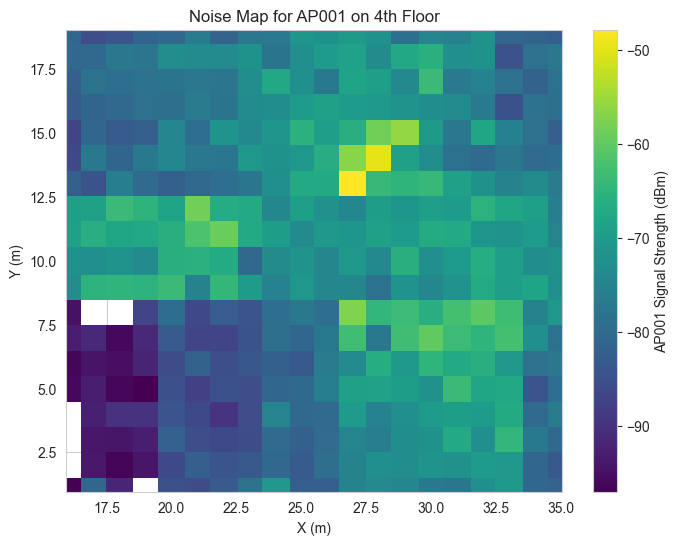

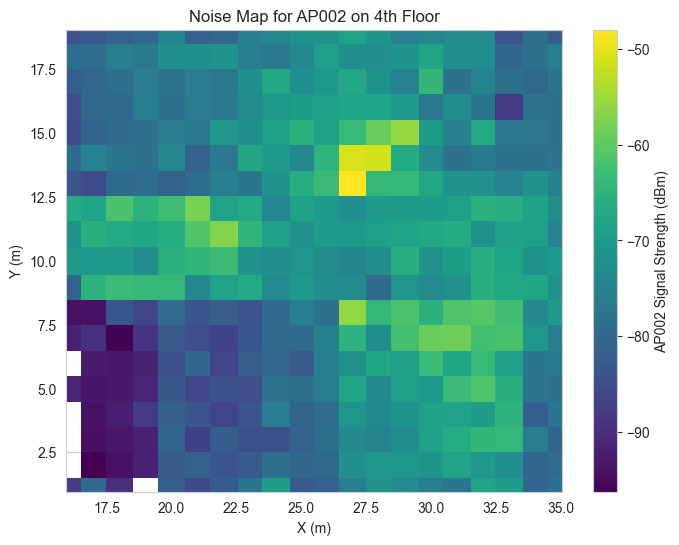

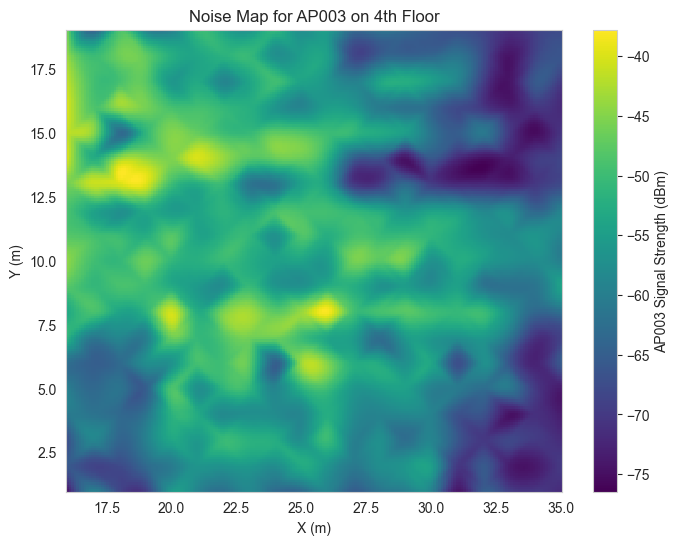

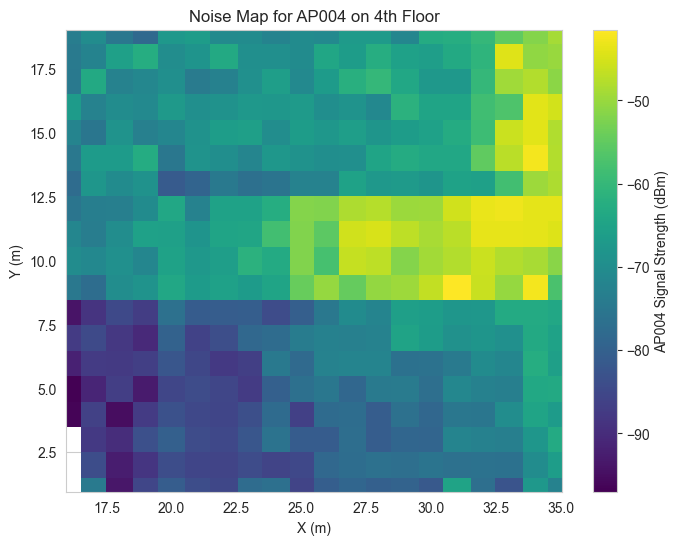

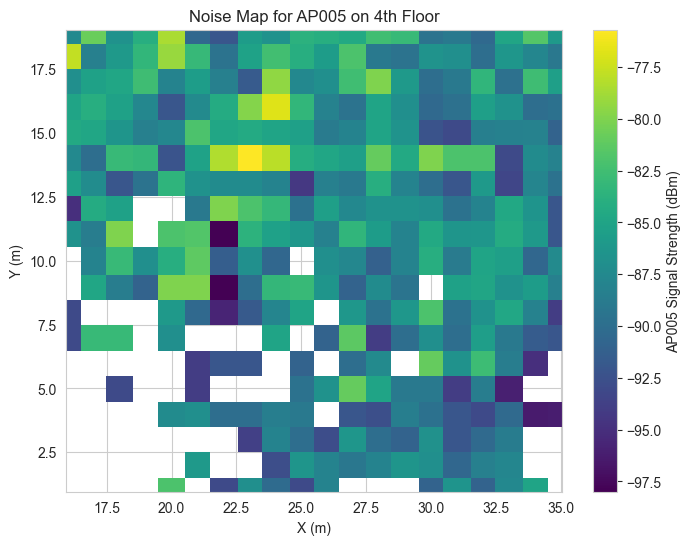

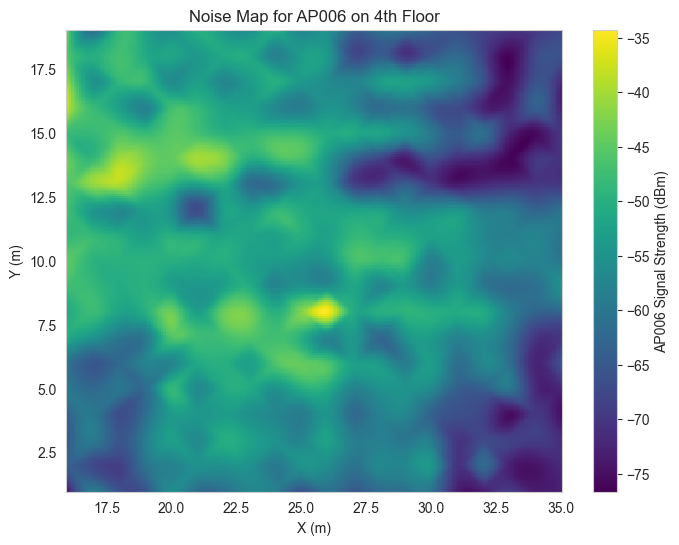

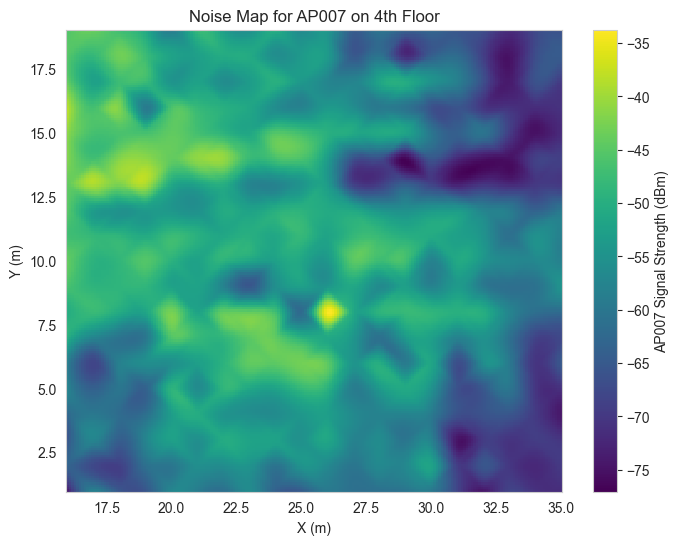

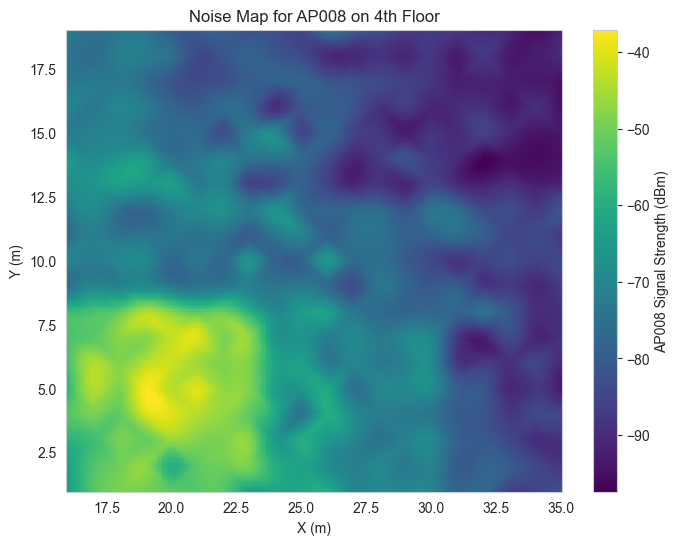

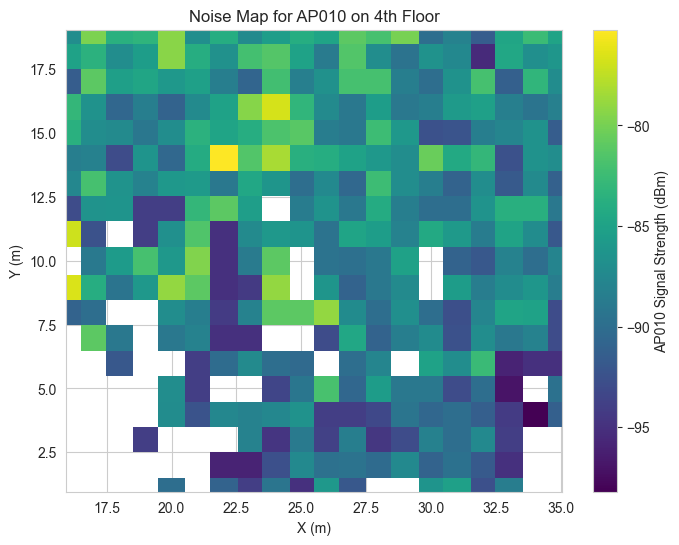

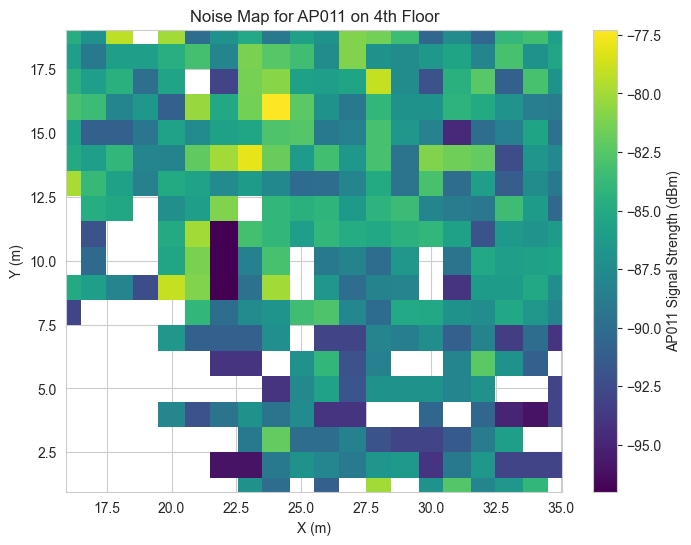

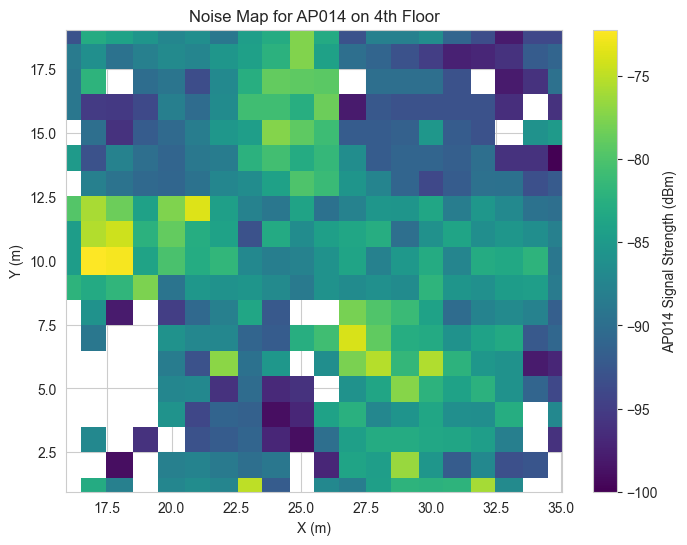

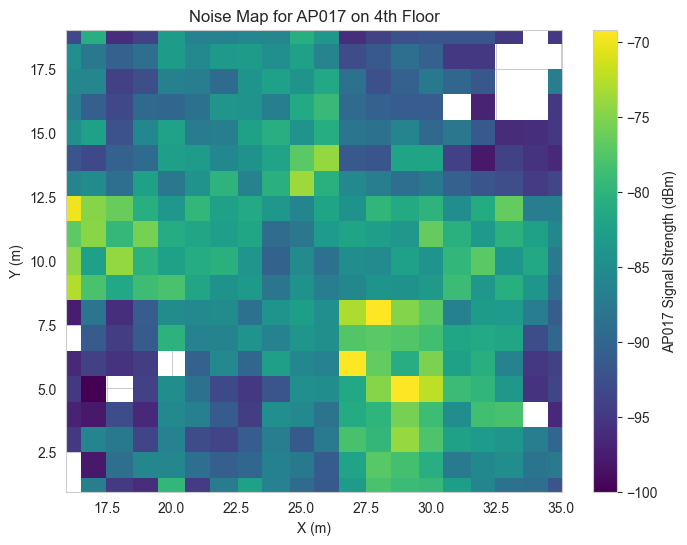

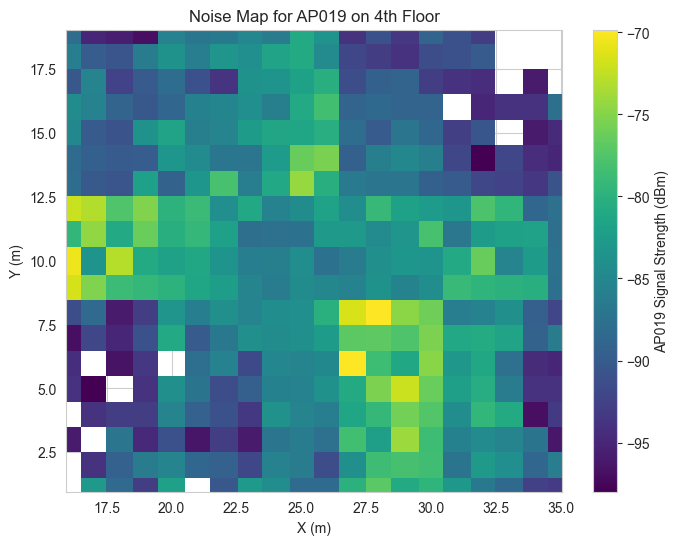

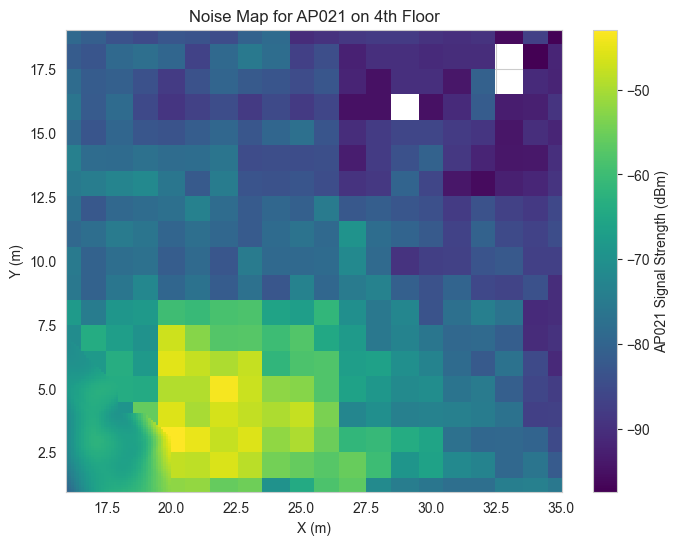

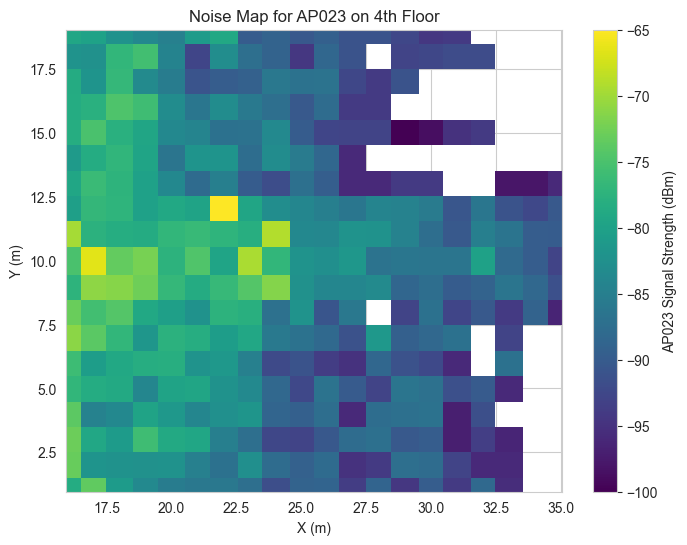

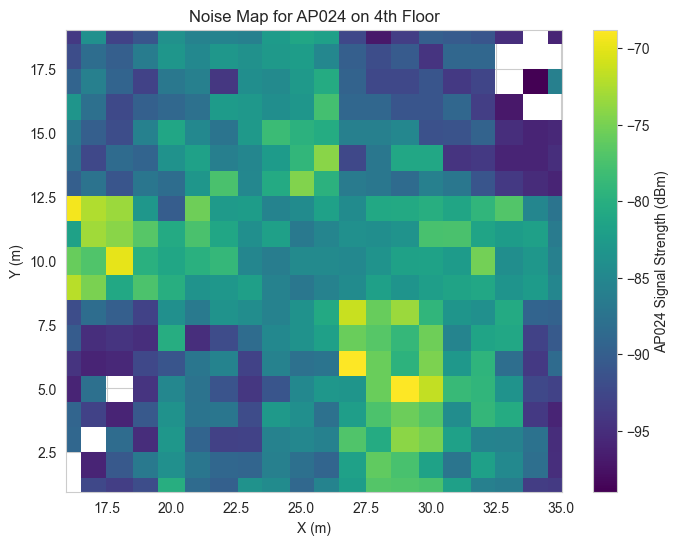

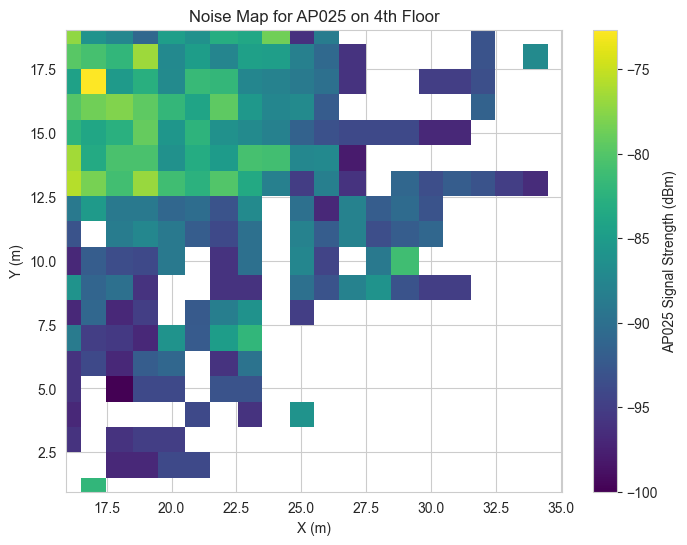

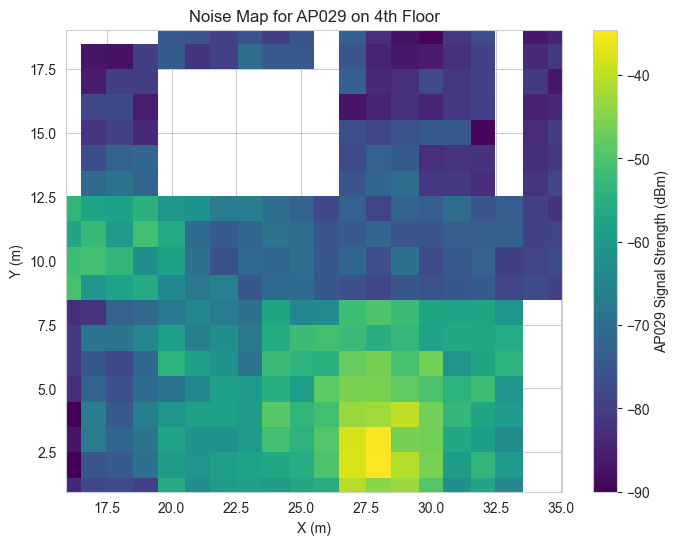

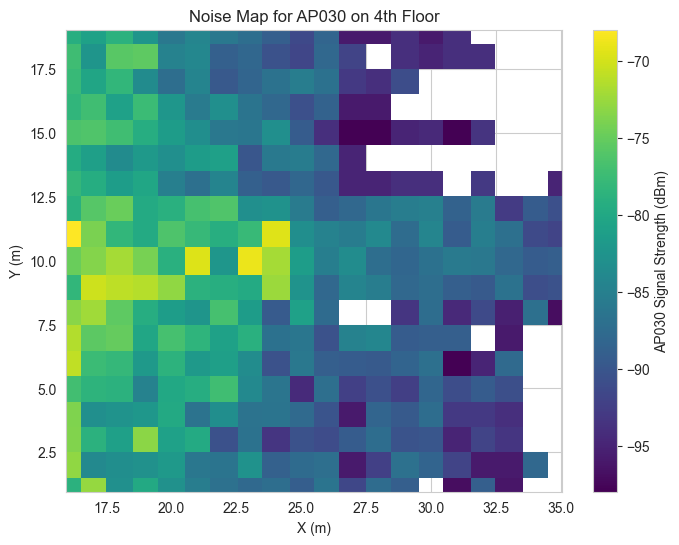

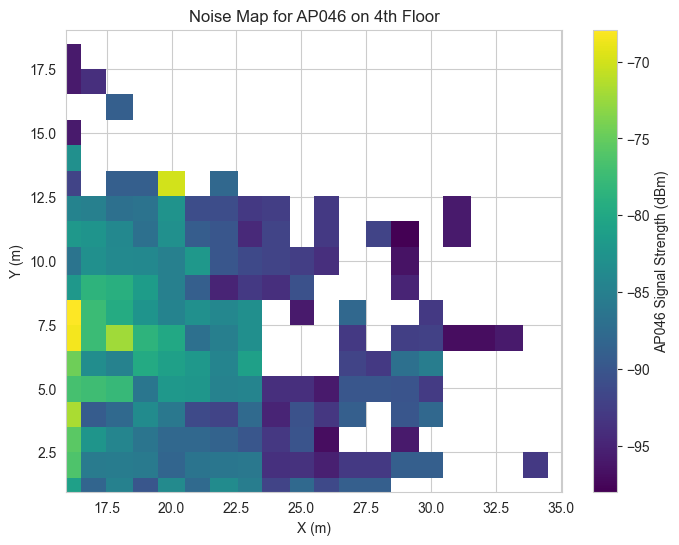

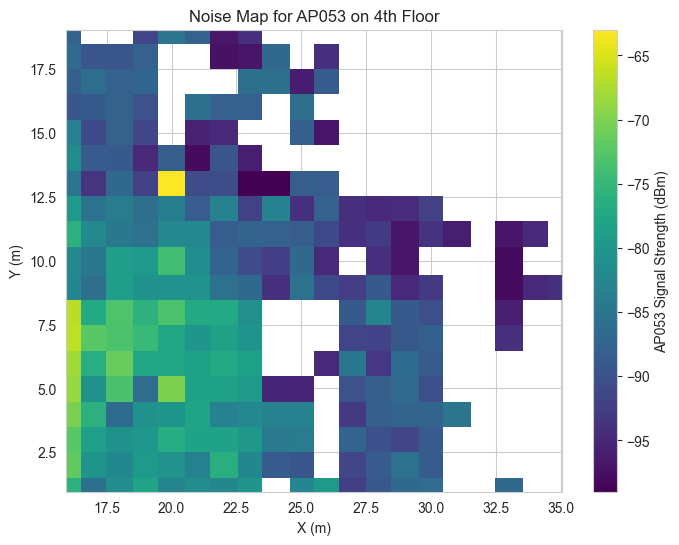

In [27]:
print("MEAN:")
for ap_col in ap_cols:
    plot_heatmap(ap_mean_by_xy, ap_col)

## Sampling Dataset Subset

In [28]:
def subsample_every_n(df, N, origin=(None,None), tol=1e-8):
    """
    Split df into two parts:
      • df_kept: rows where (X−x0) and (Y−y0) are multiples of N
      • df_rest: all the other rows

    Parameters
    ----------
    df : DataFrame with columns 'X','Y'
    N  : float           the grid spacing you want (e.g. 5.0)
    origin : (x0,y0)     the “zero” of your grid; if None, uses (min X, min Y)
    tol : float          tolerance for floating-point modulo

    Returns
    -------
    df_kept, df_rest : DataFrames
    """
    df2 = df.copy()

    # 1) determine grid origin
    x0 = origin[0] if origin[0] is not None else df2['X'].min()
    y0 = origin[1] if origin[1] is not None else df2['Y'].min()

    # 2) compute offsets
    dx = df2['X'] - x0
    dy = df2['Y'] - y0

    # 3) boolean mask for “on-grid” points
    on_grid = (
        np.isclose(dx.mod(N), 0.0, atol=tol) &
        np.isclose(dy.mod(N), 0.0, atol=tol)
    )

    # 4) split
    df_kept = df2.loc[on_grid].reset_index(drop=True)
    df_rest = df2.loc[~on_grid].reset_index(drop=True)

    return df_kept, df_rest

In [29]:
def fraction(actual, orig):
    return actual.shape[0] / orig.shape[0] * 100

## Table Diffusion Model

In [30]:
def subsample_every_n(df, N, origin=(None,None), tol=1e-8):
    """
    Split df into two parts:
      • df_kept: rows where (X−x0) and (Y−y0) are multiples of N
      • df_rest: all the other rows

    Parameters
    ----------
    df : DataFrame with columns 'X','Y'
    N  : float           the grid spacing you want (e.g. 5.0)
    origin : (x0,y0)     the “zero” of your grid; if None, uses (min X, min Y)
    tol : float          tolerance for floating-point modulo

    Returns
    -------
    df_kept, df_rest : DataFrames
    """
    df2 = df.copy()

    # 1) determine grid origin
    x0 = origin[0] if origin[0] is not None else df2['X'].min()
    y0 = origin[1] if origin[1] is not None else df2['Y'].min()

    # 2) compute offsets
    dx = df2['X'] - x0
    dy = df2['Y'] - y0

    # 3) boolean mask for “on-grid” points
    on_grid = (
        np.isclose(dx.mod(N), 0.0, atol=tol) &
        np.isclose(dy.mod(N), 0.0, atol=tol)
    )

    # 4) split
    df_kept = df2.loc[on_grid].reset_index(drop=True)
    df_rest = df2.loc[~on_grid].reset_index(drop=True)

    return df_kept, df_rest

In [31]:
def fraction(actual, orig):
    return actual.shape[0] / orig.shape[0] * 100

In [32]:
def get_beta(t: int, T: int) -> float:
    return (1.0 - math.cos(math.pi * t / T)) / 2.0

def timestep_embedding(timesteps: torch.Tensor, dim: int) -> torch.Tensor:
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(0, half, device=timesteps.device) / max(half - 1, 1))
    args = timesteps.float().unsqueeze(1) * freqs.unsqueeze(0)
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
    if dim % 2 == 1:
        emb = nn.functional.pad(emb, (0, 1))
    return emb

# Tabular U-Net-like MLP backbone
class TabularUNet(nn.Module):
    def __init__(self, input_dim: int, cond_dim: int, time_emb_dim: int, hidden: list[int] = [512, 256, 128]):
        super().__init__()
        # Heads for time and condition
        self.t_proj = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, hidden[0])
        )
        self.c_proj = nn.Sequential(
            nn.Linear(cond_dim, hidden[0]),
            nn.SiLU()
        )

        # Encoder blocks
        enc_dims = [input_dim + hidden[0]*2] + hidden[:-1]
        self.encoder = nn.ModuleList(
            nn.Sequential(nn.Linear(i, o), nn.SiLU())
            for i, o in zip(enc_dims, hidden))

        # Decoder blocks
        dec_dims = hidden[::-1]
        self.decoder = nn.ModuleList(
            nn.Sequential(nn.Linear(i*2, o), nn.SiLU())
            for i, o in zip(dec_dims[:-1], dec_dims[1:]))

        # Final layer
        self.out = nn.Linear(hidden[0], input_dim)

    def forward(self, x: torch.Tensor, cond: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        # x: [batch, input_dim]
        # cond: [batch, cond_dim]
        # t_emb: [batch, time_emb_dim]
        t_h = self.t_proj(t_emb)
        c_h = self.c_proj(cond)

        h = torch.cat([x, c_h, t_h], dim=1)
        skips = []
        # Encode
        for enc in self.encoder:
            h = enc(h)
            skips.append(h)
        # Decode
        for dec in self.decoder:
            skip = skips.pop()
            h = torch.cat([h, skip], dim=1)
            h = dec(h)
        return self.out(h)

# Diffusion model with Tabular U-Net backbone
class TableDiffusion(nn.Module):
    def __init__(self, rss_dim: int, cond_dim: int = 2, time_emb_dim: int = 128, hidden: list[int] = [512, 256, 128]):
        super().__init__()
        self.time_emb_dim = time_emb_dim
        self.unet = TabularUNet(
            rss_dim,
            cond_dim,
            time_emb_dim,
            hidden
        )

    def forward(self, noised_rss: torch.Tensor, cond: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = timestep_embedding(t, self.time_emb_dim)
        return self.unet(noised_rss, cond, t_emb)


# Training loop (noise-prediction objective)
def train_table_diffusion(
    model: TableDiffusion,
    X_cond: torch.Tensor,
    Y_rss: torch.Tensor,
    steps: int = 100,
    batch_size: int = 64,
    epochs: int = 100,
    lr: float = 6e-4,
):
    device = (
        torch.device("mps") if torch.backends.mps.is_available()
        else torch.device("cuda") if torch.cuda.is_available()
        else torch.device("cpu")
    )
    print("Device:", device)
    model.to(device)
    ds = torch.utils.data.TensorDataset(X_cond, Y_rss)
    dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)
    opt = optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()
    model.train()

    for ep in range(1, epochs+1):
        total = 0.0
        model.train()
        for cond_b, rss_b in dl:
            cond_b, rss_b = cond_b.to(device), rss_b.to(device)
            loss_acc = 0.0
            for t in range(steps):
                beta = get_beta(t, steps)
                noise = torch.randn_like(rss_b) * math.sqrt(beta)
                x_t = rss_b + noise
                t_vec = torch.full((rss_b.size(0),), t, dtype=torch.long, device=device)
                pred = model(x_t, cond_b, t_vec)
                loss_acc += mse(pred, noise)
            loss = loss_acc / steps
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item()
        if ep % 10 == 0 or ep == 1:
            print(f"[TableDiffusion] Epoch {ep}/{epochs} - loss: {total/len(dl):.4f}")
    return model

# Reverse sampling (denoise from Gaussian)
def sample_table_diffusion(
        model: TableDiffusion,
        X_cond: torch.Tensor,
        diffusion_steps: int = 100
) -> np.ndarray:
    device = (
    torch.device("mps") if torch.backends.mps.is_available()
        else torch.device("cuda") if torch.cuda.is_available()
        else torch.device("cpu")
    )
    print("Device:", device)
    model.eval()
    X_cond = X_cond.to(device)
    print(X_cond.shape)
    n, _ = X_cond.shape
    rss_dim = model.unet.out.out_features
    samples = torch.randn(n, rss_dim, device=device)

    with torch.no_grad():
        for t in reversed(range(diffusion_steps)):
            beta = get_beta(t, diffusion_steps)
            t_vec = torch.full((n,), t, dtype=torch.long, device=device)
            pred_eps = model(samples, X_cond, t_vec)
            samples = samples - pred_eps * math.sqrt(beta)
        return samples.cpu().numpy()

In [33]:
# Validation noise-prediction loss (quick proxy)
def eval_noise_mse(model, Xc, Yr, steps=50):
    device = next(model.parameters()).device
    mse = nn.MSELoss()
    model.eval()
    with torch.no_grad():
        Xc, Yr = Xc.to(device), Yr.to(device)
        tot = 0.0
        for t in range(steps):
            beta = get_beta(t, steps)
            eps = torch.randn_like(Yr) * math.sqrt(beta)
            x_t = Yr + eps
            t_vec = torch.full((Yr.size(0),), t, dtype=torch.long, device=device)
            pred = model(x_t, Xc, t_vec)
            tot += mse(pred, eps).item()
        return tot / steps


In [34]:
def train_tdm(dataset, ap_cols, cond_cols, steps=75, batch_size=64, epochs=200, lr=6.3e-4):
    # Replace missing APs with a sentinel before scaling
    td_train_filled = dataset.copy()
    td_train_filled[ap_cols] = td_train_filled[ap_cols].fillna(-110)

    # Train/val/test split
    X_cond = td_train_filled[cond_cols].values.astype("float32")
    Y_rss = td_train_filled[ap_cols].values.astype("float32")

    # Scale RSS targets only
    rss_scaler = StandardScaler()
    Y_rss_s = rss_scaler.fit_transform(Y_rss)

    print(f"Y_rss.shape: {Y_rss_s.shape}")

    # Tensors for X
    X_cond_t  = torch.tensor(X_cond,   dtype=torch.float32)
    # Tensors for Y
    Y_rss_t  = torch.tensor(Y_rss_s, dtype=torch.float32)

    # Instantiate, train, and demonstrate generation at custom coordinates
    rss_dim = len(ap_cols)
    td_model = TableDiffusion(rss_dim=rss_dim, cond_dim=2, time_emb_dim=128)

    td_model = train_table_diffusion(
        td_model,
        X_cond_t,
        Y_rss_t,
        steps=steps,          # can tune (e.g., 50–200)
        batch_size=batch_size,
        epochs=epochs,        # can tune
        lr=lr
    )

    val_noise_mse = eval_noise_mse(td_model, X_cond_t, Y_rss_t, steps=50)
    print(f"[TableDiffusion] Validation noise-prediction MSE: {val_noise_mse:.4f}")

    return td_model, X_cond_t, Y_rss_t, rss_scaler


In [35]:
def generate_rss_values(model, coords_dataset, rss_scaler, diffusion_steps=100):
    """
    Generate synthetic RSS values for the given condition columns.
    """

    gen_rss_values = sample_table_diffusion(model, coords_dataset, diffusion_steps)

    # Inverse transform to get the RSS values in the original scale
    synthetic_rss = rss_scaler.inverse_transform(gen_rss_values)

    synthetic_rss_df = pd.DataFrame(synthetic_rss, columns=ap_cols)
    return synthetic_rss_df

---

In [36]:
tdm_model_mean_aggregation, X_t_mean_aggregation, Y_t_mean_aggregation, scaler_mean_aggregation = train_tdm(ap_mean_by_xy, ap_cols=get_ap_columns(ap_mean_by_xy), cond_cols=cond_cols, epochs=600) # training Table Diffusion model on 100% of the dataset

Y_rss.shape: (380, 21)
Device: mps
[TableDiffusion] Epoch 1/600 - loss: 0.5030
[TableDiffusion] Epoch 10/600 - loss: 0.4666
[TableDiffusion] Epoch 20/600 - loss: 0.5277
[TableDiffusion] Epoch 30/600 - loss: 0.4209
[TableDiffusion] Epoch 40/600 - loss: 0.2803
[TableDiffusion] Epoch 50/600 - loss: 0.1784
[TableDiffusion] Epoch 60/600 - loss: 0.1631
[TableDiffusion] Epoch 70/600 - loss: 0.1534
[TableDiffusion] Epoch 80/600 - loss: 0.1494
[TableDiffusion] Epoch 90/600 - loss: 0.1474
[TableDiffusion] Epoch 100/600 - loss: 0.1402
[TableDiffusion] Epoch 110/600 - loss: 0.1387
[TableDiffusion] Epoch 120/600 - loss: 0.1348
[TableDiffusion] Epoch 130/600 - loss: 0.1338
[TableDiffusion] Epoch 140/600 - loss: 0.1274
[TableDiffusion] Epoch 150/600 - loss: 0.1297
[TableDiffusion] Epoch 160/600 - loss: 0.1269
[TableDiffusion] Epoch 170/600 - loss: 0.1207
[TableDiffusion] Epoch 180/600 - loss: 0.1191
[TableDiffusion] Epoch 190/600 - loss: 0.1180
[TableDiffusion] Epoch 200/600 - loss: 0.1186
[TableDiff

## KNN

In [36]:
def knn_regression(dataset):
    # Replace NaN with -110
    X_ap = dataset.drop(columns=cond_cols).fillna(-110).values
    y_xy = dataset[cond_cols].values

    scaler=StandardScaler()
    X_ap = scaler.fit_transform(X_ap)

    # KNN multi-output
    knn_xy = KNeighborsRegressor(
        n_neighbors=4,
        weights='distance',  # closer fingerprints count more
        metric='euclidean')
    knn_xy.fit(X_ap, y_xy)
    return knn_xy, scaler


## Test Dataset

In [52]:
df_test.head(5)

,Cid,AP001,AP002,AP003,AP004,AP005,AP006,AP007,AP008,AP009,...,AP170,AP171,AP172,Rs,Hpr,Did,Ts,floor,X,Y
0,L4-33-13,-77,-58,-66,-64,-92,-66,-66,-93,-93,...,-110,-110,-110,0,0,D2,1489813137748,4,33,13
1,L4-33-13,-90,-58,-78,-56,-92,-74,-74,-87,-93,...,-110,-110,-110,0,0,D2,1489813179138,4,33,13
2,L4-33-13,-80,-64,-78,-56,-92,-74,-74,-87,-93,...,-110,-110,-110,0,0,D2,1489812948443,4,33,13
3,L4-33-13,-72,-60,-74,-58,-93,-75,-76,-95,-93,...,-110,-110,-110,0,0,D2,1489812959103,4,33,13
4,L4-33-13,-82,-56,-74,-56,-93,-71,-76,-89,-110,...,-110,-110,-110,0,0,D2,1489813079167,4,33,13


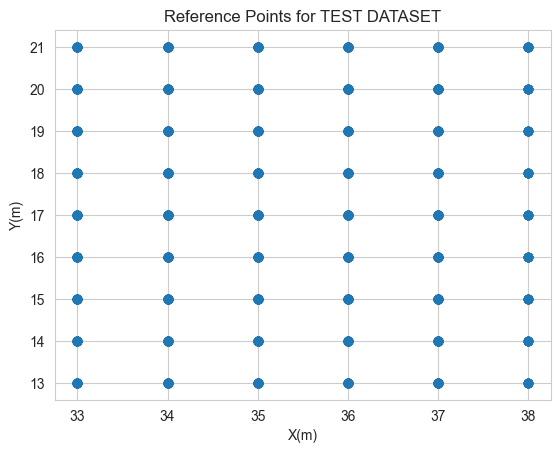

In [53]:
plot_floor_data(df_test, "Reference Points for TEST DATASET")

In [54]:
ap_cols_test_df = get_ap_columns(df_test)

In [55]:
ap_test_mean_by_xy = df_test.groupby(cond_cols)[ap_cols_test_df].mean().reset_index()
print(ap_test_mean_by_xy.shape)
ap_test_mean_by_xy.head()

(54, 174)


,X,Y,AP001,AP002,AP003,AP004,AP005,AP006,AP007,AP008,...,AP163,AP164,AP165,AP166,AP167,AP168,AP169,AP170,AP171,AP172
0,33,13,-84.500000,-61.125000,-72.75,-58.25,-93.375,-70.875,-72.250,-89.5,...,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0
1,33,14,-88.958333,-64.500000,-73.50,-47.25,-93.000,-76.250,-75.250,-95.0,...,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0
2,33,15,-84.541667,-63.458333,-70.00,-46.00,-88.250,-72.000,-69.250,-90.5,...,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0
3,33,16,-95.916667,-72.958333,-73.25,-57.00,-86.625,-72.250,-70.875,-93.5,...,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0
4,33,17,-88.916667,-63.125000,-74.50,-49.50,-89.750,-75.000,-74.000,-92.5,...,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0


In [56]:
df_test_coords = ap_test_mean_by_xy[cond_cols]
print(df_test_coords.shape)
df_test_coords.head(3)

(54, 2)


,X,Y
0,33,13
1,33,14
2,33,15


In [57]:
def generate_synthetic_rss(td_model, scaler, coordinates):
    coords_t = torch.tensor(coordinates.values,  dtype=torch.float32)
    synthetic_rss  = generate_rss_values(td_model, coords_t, scaler)

    synthetic_dataset = pd.concat([synthetic_rss, coordinates], axis=1)
    return synthetic_dataset

In [58]:
synth_dataset = generate_synthetic_rss(tdm_model_mean_aggregation, scaler_mean_aggregation, df_test_coords)
synth_dataset.head(3)

Device: mps
torch.Size([54, 2])


,AP001,AP002,AP003,AP004,AP005,AP006,AP007,AP008,AP010,AP011,...,AP021,AP023,AP024,AP025,AP029,AP030,AP046,AP053,X,Y
0,-76.736641,-75.452530,-72.683784,-53.615917,-88.232170,-73.193047,-72.207260,-89.914383,-88.648453,-87.095818,...,-92.465233,-104.461601,-93.915260,-102.869560,-90.466469,-106.091370,-108.268333,-111.876427,33,13
1,-79.142883,-78.202049,-73.921730,-50.941242,-87.250259,-73.718636,-73.112434,-91.895012,-87.744225,-86.217667,...,-92.271980,-109.341530,-95.228897,-107.904922,-89.439392,-110.306274,-108.392754,-112.072807,33,14
2,-79.541084,-78.943665,-72.793602,-50.525394,-86.067429,-72.111938,-71.313606,-91.440125,-86.613152,-85.560196,...,-91.389664,-110.143082,-95.814781,-108.658463,-86.355629,-110.270920,-107.918716,-111.750046,33,15


In [59]:
ap_test_mean_by_xy.shape, synth_dataset.shape

((54, 174), (54, 23))

In [60]:
knn_real, scaler_real = knn_regression(dataset=ap_test_mean_by_xy)
knn_synth, scaler_synth = knn_regression(dataset=synth_dataset)

In [61]:
rss_original = ap_test_mean_by_xy.drop(columns=cond_cols).fillna(-110)
all_coords = ap_test_mean_by_xy[cond_cols].values

In [62]:
pred_locations_original = knn_real.predict(scaler_real.transform(rss_original.values))
pred_locations_synthetic = knn_synth.predict(scaler_synth.transform(rss_original[ap_cols].values))

In [37]:
def plot_indoor_localization_map(true_locations, predicted_locations_orig, predicted_locations_synth, title):
    plt.figure(figsize=(8,6))
    plt.scatter(true_locations[:,0], true_locations[:,1], c='yellow', marker='x',s=100, label="True locations")
    plt.scatter(predicted_locations_orig[:,0], predicted_locations_orig[:,1], c='b', alpha=0.5, label="KNN (model trained data)")
    plt.scatter(predicted_locations_synth[:,0], predicted_locations_synth[:,1], c='r', alpha=0.5, label="KNN (synthetic data)")
    # plt.scatter(pred_locations_combined[:,0], pred_locations_combined[:,1], c='g', alpha=0.5, label="KNN (combined data)")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(title)
    plt.legend()
    plt.show()

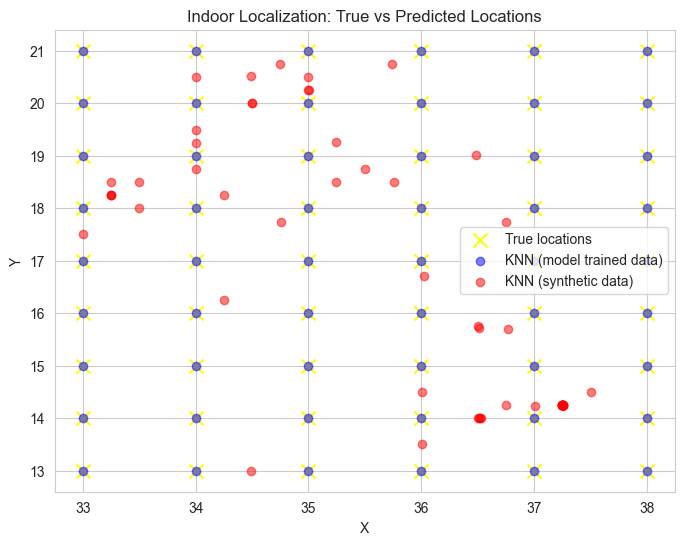

In [64]:
plot_indoor_localization_map(all_coords, pred_locations_original, pred_locations_synthetic, "Indoor Localization: True vs Predicted Locations")

In [38]:
def plot_indoor_localization_results(true_locations, predicted_locations, title):
    # Plotting
    plt.figure(figsize=(8, 6))

    # Scatter plots for the points
    plt.scatter(true_locations[:, 0], true_locations[:, 1], c='yellow', marker='x', s=100, label="True locations")
    plt.scatter(predicted_locations[:, 0], predicted_locations[:, 1], c='r', alpha=0.5, label="KNN (model trained data)")


    # Draw lines connecting the true points with synthetic predictions
    for i in range(len(true_locations)):
        plt.plot([true_locations[i, 0], predicted_locations[i, 0]],
                [true_locations[i, 1], predicted_locations[i, 1]],
                c='red', linestyle=':', linewidth=1)  # Lines between true and synthetic

    # Labels and title
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(title)
    plt.legend()

    # Show the plot
    plt.show()

In [39]:
# Define a function to compute the Euclidean distance error.
def compute_localization_errors(true_locations, predicted_locations):
    errors = np.sqrt(np.sum((true_locations - predicted_locations)**2, axis=1))
    return errors

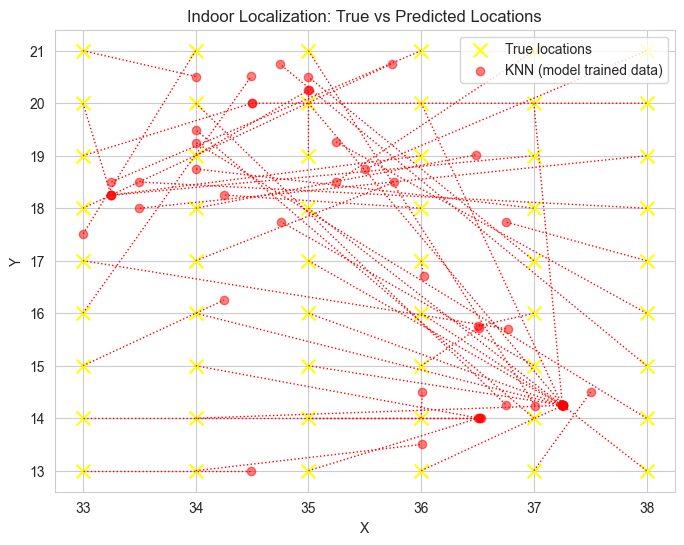

In [67]:
plot_indoor_localization_results(all_coords, pred_locations_synthetic, "Indoor Localization: True vs Predicted Locations")

In [68]:
errors_original = compute_localization_errors(all_coords, pred_locations_original)
errors_synthetic = compute_localization_errors(all_coords, pred_locations_synthetic)

mean_error_original = np.mean(errors_original)
mean_error_synthetic = np.mean(errors_synthetic)

mse_original_knn = mean_squared_error(all_coords, pred_locations_original)
mse_synthetic_knn = mean_squared_error(all_coords, pred_locations_synthetic)

print("\nKNN Localization Evaluation:")
print(f"Model trained on original data: Mean Euclidean error = {mean_error_original:.4f}, MSE = {mse_original_knn:.4f}")
print(f"Model trained on synthetic data: Mean Euclidean error = {mean_error_synthetic:.4f}, MSE = {mse_synthetic_knn:.4f}")


KNN Localization Evaluation:
Model trained on original data: Mean Euclidean error = 0.0000, MSE = 0.0000
Model trained on synthetic data: Mean Euclidean error = 3.1729, MSE = 6.5363


---

## Train Dataset

In [43]:
all_coords = ap_mean_by_xy[cond_cols]

In [44]:
synth_dataset = generate_synthetic_rss(tdm_model_mean_aggregation, scaler_mean_aggregation, all_coords)

Device: mps
torch.Size([380, 2])


In [45]:
all_coords = all_coords.values

In [46]:
ap_mean_by_xy.shape, synth_dataset.shape

((380, 23), (380, 23))

In [47]:
knn_real, scaler_real = knn_regression(dataset=ap_mean_by_xy)
knn_synth, scaler_synth = knn_regression(dataset=synth_dataset)

In [48]:
rss_original = ap_mean_by_xy.drop(columns=cond_cols).fillna(-110)

In [49]:
pred_locations_original = knn_real.predict(scaler_real.transform(rss_original[ap_cols].values))
pred_locations_synthetic = knn_synth.predict(scaler_synth.transform(rss_original[ap_cols].values))

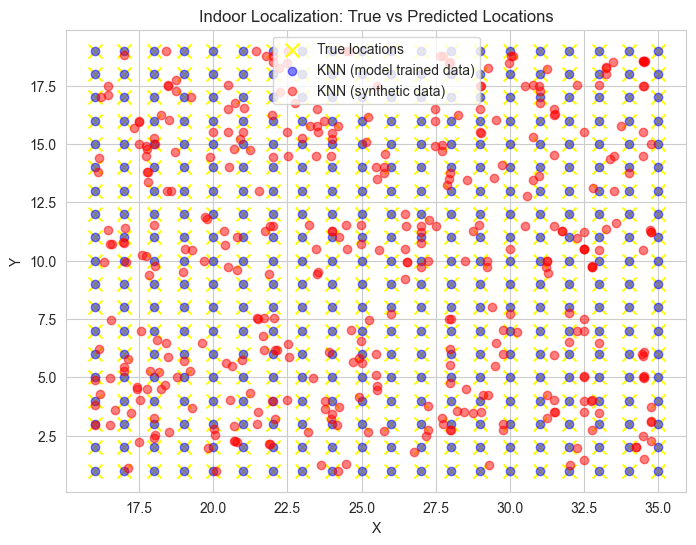

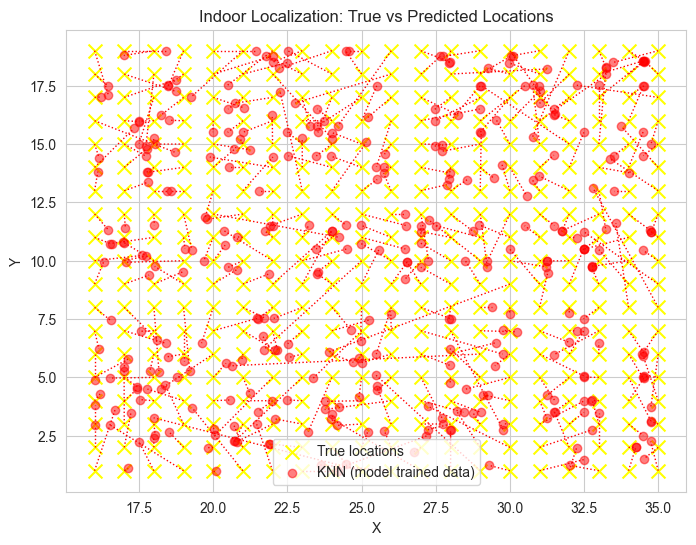

In [50]:
plot_indoor_localization_map(all_coords, pred_locations_original, pred_locations_synthetic, "Indoor Localization: True vs Predicted Locations")
plot_indoor_localization_results(all_coords, pred_locations_synthetic, "Indoor Localization: True vs Predicted Locations")

In [51]:
# Define a function to compute the Euclidean distance error.
errors_original = compute_localization_errors(all_coords, pred_locations_original)
errors_synthetic = compute_localization_errors(all_coords, pred_locations_synthetic)

mean_error_original = np.mean(errors_original)
mean_error_synthetic = np.mean(errors_synthetic)

mse_original_knn = mean_squared_error(all_coords, pred_locations_original)
mse_synthetic_knn = mean_squared_error(all_coords, pred_locations_synthetic)

print("\nKNN Localization Evaluation:")
print(f"Model trained on original data: Mean Euclidean error = {mean_error_original:.4f}, MSE = {mse_original_knn:.4f}")
print(f"Model trained on synthetic data: Mean Euclidean error = {mean_error_synthetic:.4f}, MSE = {mse_synthetic_knn:.4f}")


KNN Localization Evaluation:
Model trained on original data: Mean Euclidean error = 0.0000, MSE = 0.0000
Model trained on synthetic data: Mean Euclidean error = 1.3421, MSE = 1.4634


---

## Same floor (3rd floor), cutted sections

In [74]:
print(remaining_df_cleaned.shape)
remaining_df_cleaned.head(3)

(7637, 180)


,Cid,AP001,AP002,AP003,AP004,AP005,AP006,AP007,AP008,AP009,...,AP170,AP171,AP172,Rs,Hpr,Did,Ts,floor,X,Y
0,L4-40-1,-84,-80,-71,-58,-110,-72,-71,-110,-110,...,-110,-110,-110,0,1,D4,1469870570949,4,40,1
1,L4-40-1,-84,-79,-71,-58,-110,-72,-71,-110,-110,...,-110,-110,-110,0,1,D4,1470047205646,4,40,1
2,L4-40-1,-110,-110,-70,-56,-110,-69,-68,-110,-110,...,-110,-110,-110,0,1,D4,1469870932338,4,40,1


In [76]:
ap_mean_by_xy_remaining_df = remaining_df_cleaned.groupby(['X', 'Y'])[get_ap_columns(remaining_df_cleaned)].mean().reset_index()
print(ap_mean_by_xy_remaining_df.shape)
ap_mean_by_xy_remaining_df.head()

(265, 174)


,X,Y,AP001,AP002,AP003,AP004,AP005,AP006,AP007,AP008,...,AP163,AP164,AP165,AP166,AP167,AP168,AP169,AP170,AP171,AP172
0,1,9,-85.25,-82.6875,-67.750000,-62.500000,-110.0,-67.750000,-64.000000,-81.5,...,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0
1,4,9,-100.50,-97.0000,-61.000000,-92.000000,-110.0,-62.000000,-59.500000,-82.5,...,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0
2,4,10,-91.50,-92.0000,-50.333333,-92.666667,-110.0,-50.333333,-53.666667,-86.0,...,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0
3,4,11,-93.00,-91.7500,-62.000000,-91.000000,-110.0,-60.500000,-59.000000,-75.5,...,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0
4,4,12,-93.75,-94.3750,-59.500000,-91.000000,-110.0,-59.500000,-57.000000,-79.0,...,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0


In [77]:
all_coords = ap_mean_by_xy_remaining_df[cond_cols]
synth_dataset = generate_synthetic_rss(tdm_model_mean_aggregation, scaler_mean_aggregation, all_coords)
all_coords = all_coords.values

Device: mps
torch.Size([265, 2])


In [78]:
ap_mean_by_xy_remaining_df.shape, synth_dataset.shape

((265, 174), (265, 23))

In [79]:
knn_real, scaler_real = knn_regression(dataset=ap_mean_by_xy_remaining_df)
knn_synth, scaler_synth = knn_regression(dataset=synth_dataset)

In [80]:
rss_original = ap_mean_by_xy_remaining_df.drop(columns=cond_cols).fillna(-110)

In [81]:
pred_locations_original = knn_real.predict(scaler_real.transform(rss_original.values))
pred_locations_synthetic = knn_synth.predict(scaler_synth.transform(rss_original[get_ap_columns(synth_dataset)].values))

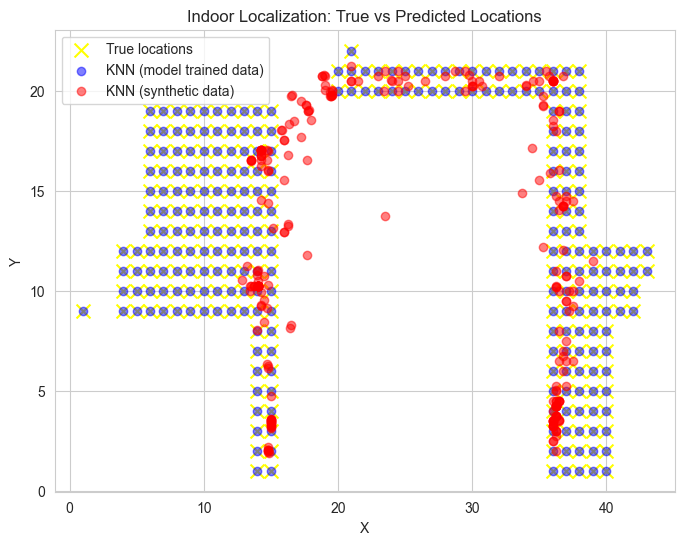

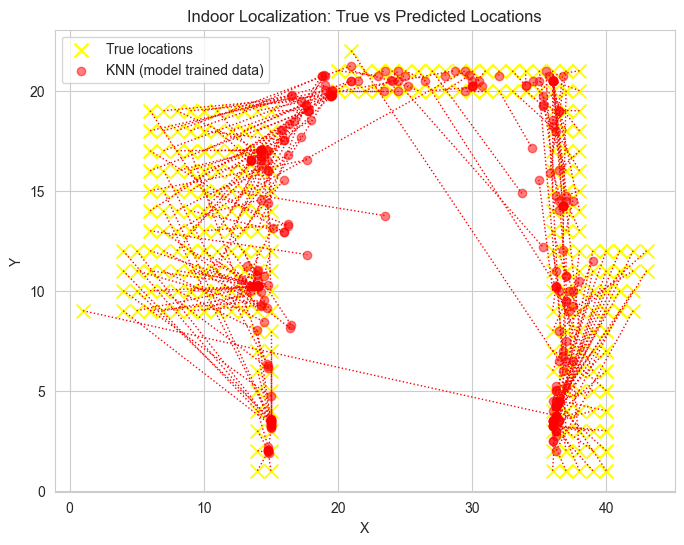

In [82]:
plot_indoor_localization_map(all_coords, pred_locations_original, pred_locations_synthetic, "Indoor Localization: True vs Predicted Locations")
plot_indoor_localization_results(all_coords, pred_locations_synthetic, "Indoor Localization: True vs Predicted Locations")

In [83]:
# Define a function to compute the Euclidean distance error.
errors_original = compute_localization_errors(all_coords, pred_locations_original)
errors_synthetic = compute_localization_errors(all_coords, pred_locations_synthetic)

mean_error_original = np.mean(errors_original)
mean_error_synthetic = np.mean(errors_synthetic)

mse_original_knn = mean_squared_error(all_coords, pred_locations_original)
mse_synthetic_knn = mean_squared_error(all_coords, pred_locations_synthetic)

print("\nKNN Localization Evaluation:")
print(f"Model trained on original data: Mean Euclidean error = {mean_error_original:.4f}, MSE = {mse_original_knn:.4f}")
print(f"Model trained on synthetic data: Mean Euclidean error = {mean_error_synthetic:.4f}, MSE = {mse_synthetic_knn:.4f}")


KNN Localization Evaluation:
Model trained on original data: Mean Euclidean error = 0.0000, MSE = 0.0000
Model trained on synthetic data: Mean Euclidean error = 5.4209, MSE = 25.2397


---

## Approach 2: Will not aggregate data before training the Table Diffusion Model

In [43]:
print("Training dataset:", square_df_cleaned.shape)
square_df_cleaned.head(3)

Training dataset: (10379, 26)


,Cid,AP001,AP002,AP003,AP004,AP005,AP006,AP007,AP008,AP010,...,AP024,AP029,AP030,Rs,Hpr,Did,Ts,floor,X,Y
256,L4-34-1,-80.0,-81.0,-70.0,-63.0,-85.0,-75.0,-69.0,NaN,NaN,...,NaN,NaN,NaN,0,0,D4,1469963153060,4,34,1
257,L4-34-1,-80.0,-81.0,-70.0,-63.0,-85.0,-75.0,-69.0,NaN,NaN,...,NaN,NaN,NaN,0,0,D4,1470139819109,4,34,1
258,L4-34-1,-80.0,-80.0,-70.0,-63.0,-85.0,-75.0,-69.0,NaN,NaN,...,NaN,NaN,NaN,0,0,D4,1469962304939,4,34,1


In [44]:
feature_columns = [col for col in square_df_cleaned.columns if col.startswith('AP')]
coordinate_columns = ['X','Y']
len(feature_columns)

18

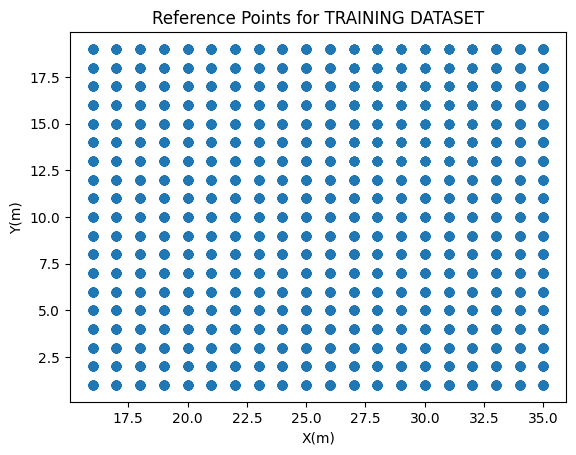

In [45]:
plot_floor_data(square_df_cleaned, "Reference Points for TRAINING DATASET")

In [48]:
td_model, X_t, Y_t, scaler = train_tdm(square_df_cleaned, ap_cols=feature_columns, cond_cols=coordinate_columns, epochs=200, batch_size=256)

Y_rss.shape: (10379, 18)
Device: cuda
[TableDiffusion] Epoch 1/200 - loss: 0.4926
[TableDiffusion] Epoch 10/200 - loss: 0.1946
[TableDiffusion] Epoch 20/200 - loss: 0.1726
[TableDiffusion] Epoch 30/200 - loss: 0.1604
[TableDiffusion] Epoch 40/200 - loss: 0.1512
[TableDiffusion] Epoch 50/200 - loss: 0.1416
[TableDiffusion] Epoch 60/200 - loss: 0.1348
[TableDiffusion] Epoch 70/200 - loss: 0.1272
[TableDiffusion] Epoch 80/200 - loss: 0.1215
[TableDiffusion] Epoch 90/200 - loss: 0.1165
[TableDiffusion] Epoch 100/200 - loss: 0.1105
[TableDiffusion] Epoch 110/200 - loss: 0.1065
[TableDiffusion] Epoch 120/200 - loss: 0.1007
[TableDiffusion] Epoch 130/200 - loss: 0.0964
[TableDiffusion] Epoch 140/200 - loss: 0.0923
[TableDiffusion] Epoch 150/200 - loss: 0.0886
[TableDiffusion] Epoch 160/200 - loss: 0.0845
[TableDiffusion] Epoch 170/200 - loss: 0.0809
[TableDiffusion] Epoch 180/200 - loss: 0.0774
[TableDiffusion] Epoch 190/200 - loss: 0.0745
[TableDiffusion] Epoch 200/200 - loss: 0.0720
[TableD

In [53]:
all_coords = square_df_cleaned[coordinate_columns]
synth_dataset = generate_synthetic_rss(td_model, scaler, all_coords)

all_coords = all_coords.values # Coordinate columns: (X,Y)
rss_original = square_df_cleaned[feature_columns].fillna(-110)

Device: cuda
torch.Size([10379, 2])


In [54]:
ap_mean_by_xy_approach2 = square_df_cleaned.groupby(['X', 'Y'])[feature_columns].mean().reset_index()
print(ap_mean_by_xy_approach2.shape)
ap_mean_by_xy_approach2.head()

(380, 20)


,X,Y,AP001,AP002,AP003,AP004,AP005,AP006,AP007,AP008,AP010,AP011,AP014,AP017,AP019,AP021,AP023,AP024,AP029,AP030
0,16,1,-96.625,-87.5,-73.900000,NaN,NaN,-73.266667,-73.400000,-64.400000,NaN,NaN,NaN,NaN,NaN,-79.933333,-78.400000,NaN,-84.0,-78.800000
1,16,2,NaN,NaN,-65.892857,NaN,NaN,-63.821429,-63.500000,-63.285714,NaN,NaN,NaN,NaN,NaN,-73.928571,-73.142857,NaN,-90.0,-73.000000
2,16,3,NaN,NaN,-66.750000,NaN,NaN,-64.821429,-65.357143,-58.714286,NaN,NaN,NaN,-95.0,-96.0,-71.642857,-72.857143,-89.00,-87.0,-73.642857
3,16,4,NaN,NaN,-60.857143,-96.5,NaN,-63.208333,-62.500000,-53.428571,NaN,NaN,NaN,-97.0,NaN,-71.230769,-73.857143,-89.25,-90.0,-73.785714
4,16,5,-96.000,-91.5,-60.107143,-97.0,NaN,-59.392857,-57.857143,-57.642857,NaN,NaN,NaN,-95.0,-94.0,-68.000000,-76.928571,-96.00,-83.0,-77.071429


In [55]:
ap_mean_by_xy_synth_approach2 = synth_dataset.groupby(['X', 'Y'])[feature_columns].mean().reset_index()
print(ap_mean_by_xy_synth_approach2.shape)
ap_mean_by_xy_synth_approach2.head()

(380, 20)


,X,Y,AP001,AP002,AP003,AP004,AP005,AP006,AP007,AP008,AP010,AP011,AP014,AP017,AP019,AP021,AP023,AP024,AP029,AP030
0,16.0,1.0,-78.508316,-72.950935,-63.508907,-58.472279,-108.633080,-62.584431,-63.725765,-95.911301,-107.883110,-109.463234,-90.928947,-98.677589,-92.434082,-92.120804,-110.900093,-93.693787,-84.971375,-109.107376
1,16.0,2.0,-72.883080,-73.142479,-59.978512,-66.407539,-106.246544,-57.625477,-60.014755,-75.981819,-104.345268,-106.764992,-94.231445,-94.215080,-91.971443,-84.247963,-87.068024,-91.946358,-89.975586,-87.814667
2,16.0,3.0,-65.321587,-65.427177,-58.350864,-61.628361,-98.475616,-59.660767,-58.022533,-81.191017,-97.818481,-101.742455,-93.670570,-82.506004,-84.380280,-91.038948,-103.785408,-81.264519,-81.915794,-98.961723
3,16.0,4.0,-63.428761,-60.593006,-53.477161,-61.581020,-105.391151,-54.105621,-51.943527,-78.897850,-105.649712,-105.381508,-86.423157,-86.362679,-84.417564,-87.725609,-87.179405,-84.477745,-89.144440,-88.792641
4,16.0,5.0,-65.939072,-62.473255,-54.745865,-58.528408,-99.946075,-56.065014,-53.193329,-90.132027,-100.874931,-99.996948,-83.185265,-82.228798,-81.744423,-83.160393,-94.598503,-80.284157,-77.299751,-99.792519


In [111]:
dataset_df = ap_mean_by_xy_approach2.fillna(-110).reset_index(drop=True)
synth_dataset = ap_mean_by_xy_synth_approach2.fillna(-110).reset_index(drop=True)

dataset_df.shape, synth_dataset.shape

((380, 20), (380, 20))

In [112]:
knn_real, scaler_real = knn_regression(dataset=dataset_df)
knn_synth, scaler_synth = knn_regression(dataset=synth_dataset)

In [113]:
pred_locations_original = knn_real.predict(scaler_real.transform(rss_original[feature_columns]))
pred_locations_synthetic = knn_synth.predict(scaler_synth.transform(rss_original[feature_columns]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


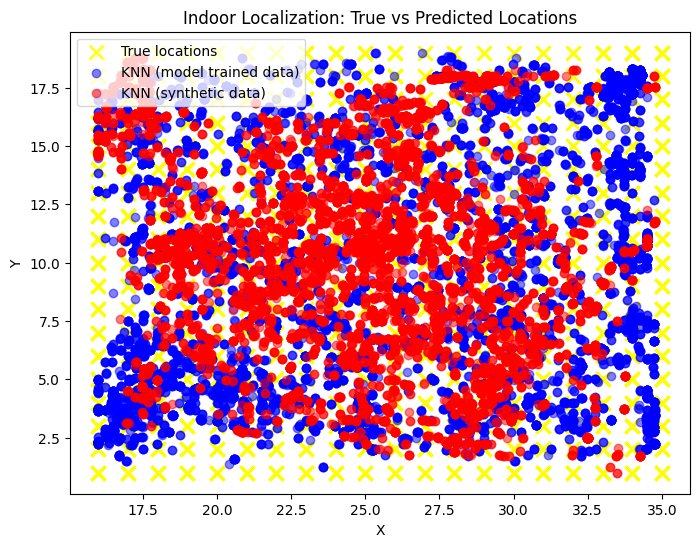

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


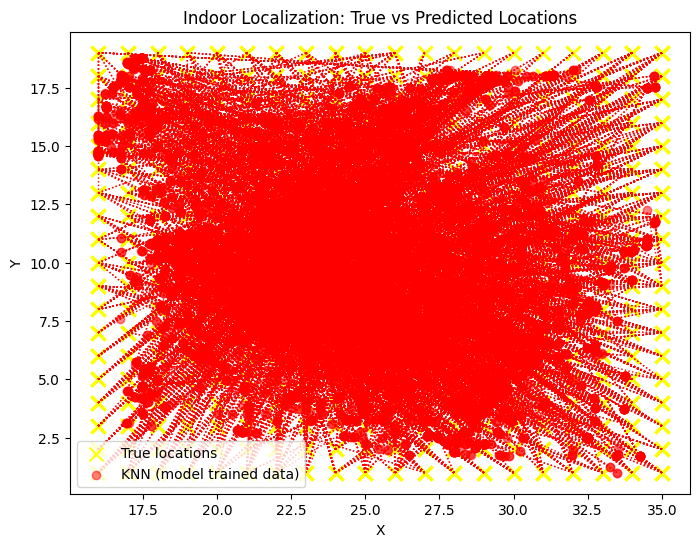

In [114]:
plot_indoor_localization_map(all_coords, pred_locations_original, pred_locations_synthetic, "Indoor Localization: True vs Predicted Locations")
plot_indoor_localization_results(all_coords, pred_locations_synthetic, "Indoor Localization: True vs Predicted Locations")

In [115]:
# Define a function to compute the Euclidean distance error.
errors_original = compute_localization_errors(all_coords, pred_locations_original)
errors_synthetic = compute_localization_errors(all_coords, pred_locations_synthetic)

mean_error_original = np.mean(errors_original)
mean_error_synthetic = np.mean(errors_synthetic)

mse_original_knn = mean_squared_error(all_coords, pred_locations_original)
mse_synthetic_knn = mean_squared_error(all_coords, pred_locations_synthetic)

print("\nKNN Localization Evaluation:")
print(f"Model trained on original data: Mean Euclidean error = {mean_error_original:.4f}, MSE = {mse_original_knn:.4f}")
print(f"Model trained on synthetic data: Mean Euclidean error = {mean_error_synthetic:.4f}, MSE = {mse_synthetic_knn:.4f}")


KNN Localization Evaluation:
Model trained on original data: Mean Euclidean error = 4.5024, MSE = 16.7220
Model trained on synthetic data: Mean Euclidean error = 9.8059, MSE = 56.6118


## Approach 3

Filtering the feature columns with PCA

In [78]:
def plot_variance(pca, width=8, dpi=100):
    # Create figure
    fig, axs = plt.subplots(1, 2)
    n = pca.n_components_
    grid = np.arange(1, n + 1)
    # Explained variance
    evr = pca.explained_variance_ratio_
    axs[0].bar(grid, evr)
    axs[0].set(
        xlabel="Component", title="% Explained Variance", ylim=(0.0, 1.0)
    )
    # Cumulative Variance
    cv = np.cumsum(evr)
    axs[1].plot(np.r_[0, grid], np.r_[0, cv], "o-")
    axs[1].set(
        xlabel="Component", title="% Cumulative Variance", ylim=(0.0, 1.0)
    )
    # Set up figure
    fig.set(figwidth=16, dpi=100)
    return axs

def apply_pca(dataset):
    pca = PCA()
    X_pca = pca.fit_transform(dataset[ap_cols].fillna(-110))

    component_names = [f'PC{i+1}' for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=component_names)

    # --------

    loadings = pd.DataFrame(
        pca.components_.T,  # transpose the matrix of loadings
        columns=component_names,  # so the columns are the principal components
        index=square_df_cleaned[ap_cols].columns,  # and the rows are the original features
    )

    return X_pca, loadings, pca

In [79]:
X_pca_mean, loadings_mean, pca_mean = apply_pca(ap_mean_by_xy)

In [80]:
loadings_mean

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18
AP001,-0.150603,0.331449,0.064137,-0.168121,-0.073334,-0.009367,-0.215034,0.134760,0.488627,-0.124029,0.116933,0.001578,-0.042247,0.022667,-0.020828,0.033087,-0.679554,0.178273
AP002,-0.144142,0.322428,0.064477,-0.187867,-0.068960,-0.032116,-0.189090,0.185759,0.480199,-0.108541,0.114598,0.037619,0.019915,0.024582,0.005527,0.025351,0.683636,-0.183878
AP003,0.120503,0.167762,-0.315301,0.071962,0.055710,0.283018,-0.268619,0.092858,-0.070692,0.010609,-0.087802,0.055466,-0.036260,0.030727,0.162245,-0.671648,-0.112540,-0.424859
AP004,-0.336440,0.193676,0.014000,0.015213,0.637183,0.440020,0.440119,-0.177154,0.081988,-0.109752,0.067183,0.009969,-0.009931,0.002788,-0.023751,-0.004754,0.009385,0.000962
AP005,-0.161364,0.222380,-0.126568,0.403199,-0.104296,-0.252321,0.105601,-0.007264,-0.035840,-0.604473,-0.530788,0.053730,0.080443,0.036557,-0.018555,0.022208,0.007142,0.013423
AP006,0.126131,0.158131,-0.315150,0.076380,0.066131,0.276591,-0.278641,0.105883,-0.115890,0.001356,-0.008345,0.016851,0.045801,-0.052092,-0.009339,-0.058496,0.212676,0.785409
AP007,0.125861,0.162503,-0.325734,0.070877,0.059768,0.294323,-0.255725,0.130296,-0.164921,0.013471,-0.033940,-0.059021,-0.046418,0.020333,-0.172976,0.690257,-0.078662,-0.356242
AP008,0.451847,-0.133165,-0.124095,0.098593,-0.062035,0.093259,0.249797,-0.000820,0.243342,-0.201199,0.225089,0.714734,0.025647,0.034494,-0.114344,0.035834,-0.021457,-0.012800
AP010,-0.139045,0.208807,-0.136071,0.408927,-0.156282,-0.174554,0.094333,0.023935,-0.220882,-0.149231,0.760910,-0.174784,-0.037558,-0.024243,0.025443,-0.051328,0.001344,-0.033010
AP011,-0.190366,0.198710,-0.121104,0.483635,-0.181414,-0.022196,0.084591,-0.223189,0.273152,0.672077,-0.163903,0.168604,-0.029536,0.009709,-0.034719,0.035524,0.011299,0.013454


In [81]:
# Display PCA components sorted by explained variance (descending)
explained_variance = pd.Series(pca_mean.explained_variance_ratio_, index=[f'PC{i+1}' for i in range(pca_mean.n_components_)])
explained_variance.sort_values(ascending=False)

,0
PC1,0.380324
PC2,0.235610
PC3,0.161116
PC4,0.051254
PC5,0.041402
PC6,0.031966
PC7,0.020960
PC8,0.016398
PC9,0.015315
PC10,0.014038


array([<Axes: title={'center': '% Explained Variance'}, xlabel='Component'>,
       <Axes: title={'center': '% Cumulative Variance'}, xlabel='Component'>],
      dtype=object)

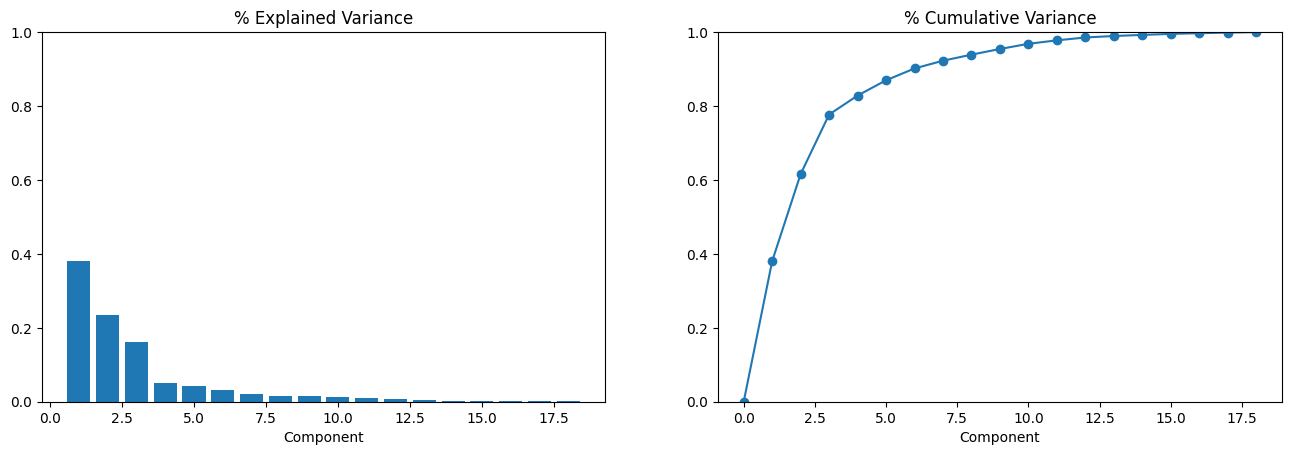

In [82]:
plot_variance(pca_mean)

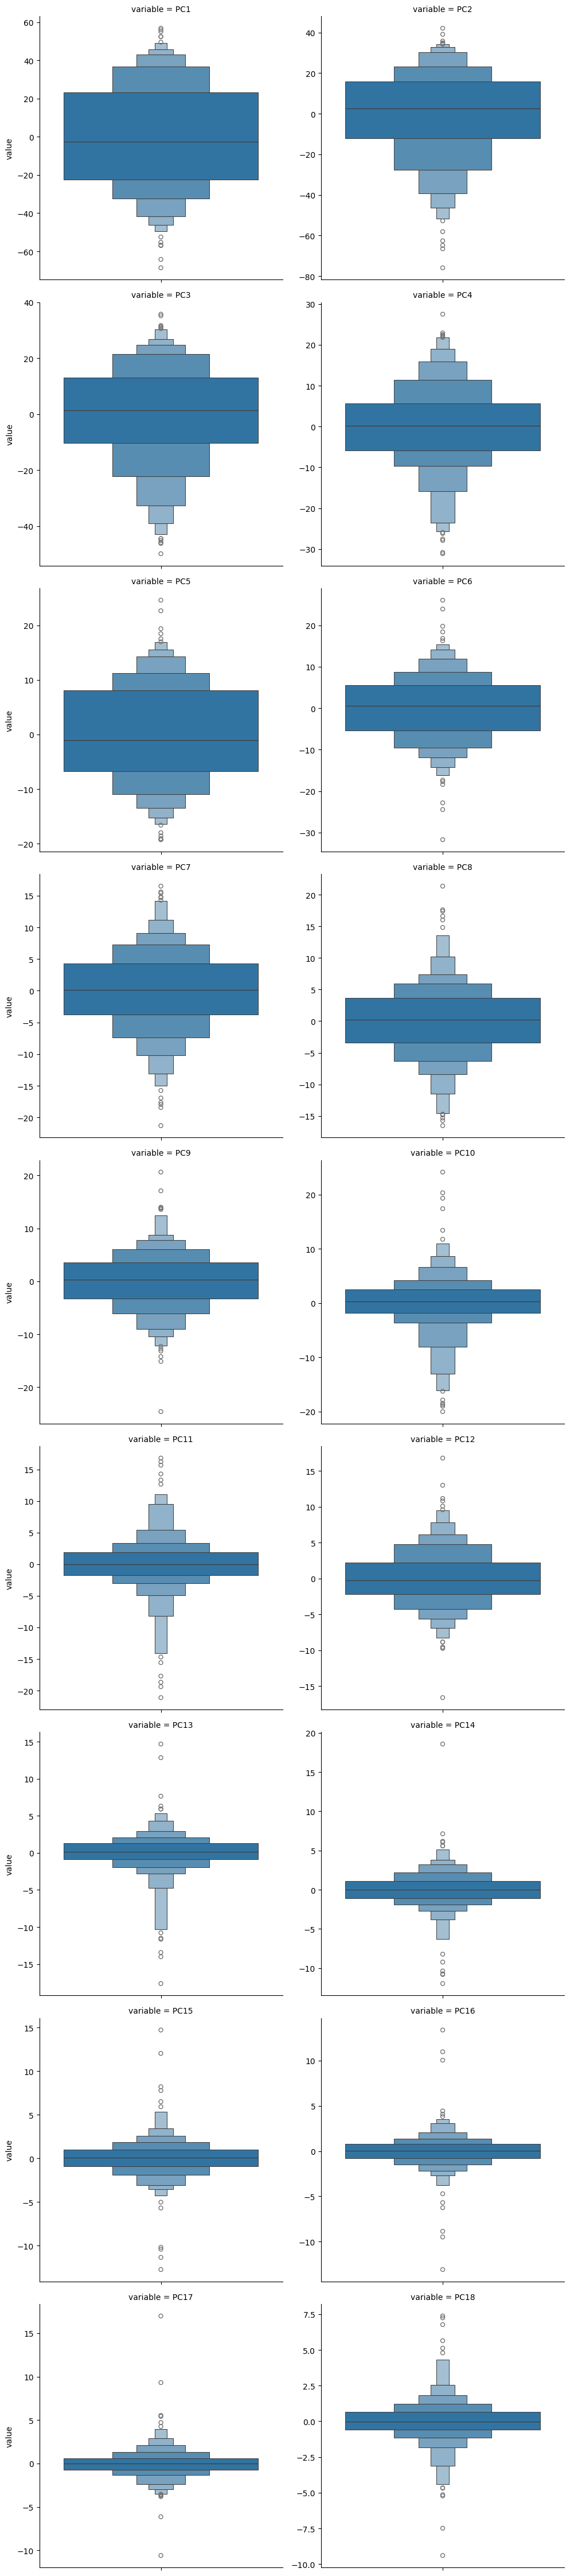

In [83]:
sns.catplot(
    y="value",
    col="variable",
    data=X_pca_mean.melt(),
    kind='boxen',
    sharey=False,
    col_wrap=2,
);

In [84]:
X_pca_mean

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18
0,23.229696,-66.565788,11.402514,-3.803119,3.216289,-31.706029,-14.206528,9.156925,6.850184,6.098063,-0.915299,-1.956547,1.968551,1.136165,1.776028,0.390438,4.256077,-1.396310
1,34.964944,-75.896172,-6.790663,3.198298,7.073576,-24.437685,-10.078782,5.584756,-9.003789,10.073769,-6.228768,-7.626072,1.740444,0.307478,1.780099,0.200693,-1.649458,0.966475
2,41.023372,-62.635343,-6.361197,-8.330653,-3.839915,-22.814430,-3.542984,-11.665758,-14.231992,7.679812,-5.920758,-2.971522,-3.060089,-3.764591,1.746831,-0.165278,-0.996414,1.276975
3,37.976418,-64.902270,-10.787271,-3.181135,7.089389,-13.432215,0.589409,-6.738734,-10.361614,4.769076,-4.951807,0.595233,-13.439097,-1.512729,1.539775,-2.200935,-1.053893,-0.296739
4,35.920245,-46.616688,-5.065540,-9.002036,2.002671,-8.144145,-9.903900,-4.494805,0.488677,2.403838,-1.768532,-2.432758,1.912317,0.810516,1.203920,1.170605,1.837952,-0.960587
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,-40.967368,-13.522466,26.571087,3.941409,8.073601,5.792950,8.941118,4.111148,-9.963274,3.240102,-2.202516,1.303331,1.884091,0.102956,0.135280,-2.096484,2.007684,0.583787
376,-44.605765,-17.812153,25.978369,9.056502,10.001608,7.317666,5.598544,-2.075689,-3.844774,0.174304,1.985214,-3.523101,14.694664,7.133245,1.486615,0.370212,-0.982708,-1.234628
377,-45.802959,-13.509932,21.267458,7.310028,2.685884,2.621590,7.084558,1.840075,-7.526240,-1.262924,-2.764213,0.685831,-17.634194,4.228588,2.009476,-0.277481,0.946637,0.076988
378,-41.952043,-21.079241,22.119646,21.812613,15.190062,6.896570,-1.770028,17.617873,0.388339,2.462781,1.894958,1.209542,1.058534,1.123369,-1.099930,0.013624,0.141942,-0.556066


In [85]:
coordinate_data = ap_mean_by_xy[['X', 'Y']]
pca_transformed_dataset_for_tdm = pd.concat([coordinate_data, X_pca_mean], axis=1)

print(pca_transformed_dataset_for_tdm.head())
print(f"Shape of pca_transformed_dataset_for_tdm: {pca_transformed_dataset_for_tdm.shape}")

    X  Y        PC1        PC2        PC3       PC4       PC5        PC6  \
0  16  1  23.229696 -66.565788  11.402514 -3.803119  3.216289 -31.706029   
1  16  2  34.964944 -75.896172  -6.790663  3.198298  7.073576 -24.437685   
2  16  3  41.023372 -62.635343  -6.361197 -8.330653 -3.839915 -22.814430   
3  16  4  37.976418 -64.902270 -10.787271 -3.181135  7.089389 -13.432215   
4  16  5  35.920245 -46.616688  -5.065540 -9.002036  2.002671  -8.144145   

         PC7        PC8        PC9       PC10      PC11      PC12       PC13  \
0 -14.206528   9.156925   6.850184   6.098063 -0.915299 -1.956547   1.968551   
1 -10.078782   5.584756  -9.003789  10.073769 -6.228768 -7.626072   1.740444   
2  -3.542984 -11.665758 -14.231992   7.679812 -5.920758 -2.971522  -3.060089   
3   0.589409  -6.738734 -10.361614   4.769076 -4.951807  0.595233 -13.439097   
4  -9.903900  -4.494805   0.488677   2.403838 -1.768532 -2.432758   1.912317   

       PC14      PC15      PC16      PC17      PC18  
0  1.136

In [86]:
pca_feature_columns = [col for col in pca_transformed_dataset_for_tdm.columns if col.startswith('PC')]
print(f"PCA feature columns: {pca_feature_columns}")

PCA feature columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18']


In [87]:
pca_tdm_model, pca_X_t, pca_Y_t, pca_scaler = train_tdm(
    dataset=pca_transformed_dataset_for_tdm,
    ap_cols=pca_feature_columns,
    cond_cols=cond_cols,
    epochs=200,
    batch_size=64
)

Y_rss.shape: (380, 18)
Device: cuda
[TableDiffusion] Epoch 1/200 - loss: 0.5050
[TableDiffusion] Epoch 10/200 - loss: 0.4707
[TableDiffusion] Epoch 20/200 - loss: 0.4764
[TableDiffusion] Epoch 30/200 - loss: 0.3334
[TableDiffusion] Epoch 40/200 - loss: 0.2735
[TableDiffusion] Epoch 50/200 - loss: 0.2610
[TableDiffusion] Epoch 60/200 - loss: 0.2469
[TableDiffusion] Epoch 70/200 - loss: 0.2394
[TableDiffusion] Epoch 80/200 - loss: 0.2272
[TableDiffusion] Epoch 90/200 - loss: 0.2162
[TableDiffusion] Epoch 100/200 - loss: 0.2057
[TableDiffusion] Epoch 110/200 - loss: 0.2003
[TableDiffusion] Epoch 120/200 - loss: 0.1937
[TableDiffusion] Epoch 130/200 - loss: 0.1863
[TableDiffusion] Epoch 140/200 - loss: 0.1841
[TableDiffusion] Epoch 150/200 - loss: 0.1808
[TableDiffusion] Epoch 160/200 - loss: 0.1746
[TableDiffusion] Epoch 170/200 - loss: 0.1754
[TableDiffusion] Epoch 180/200 - loss: 0.1674
[TableDiffusion] Epoch 190/200 - loss: 0.1649
[TableDiffusion] Epoch 200/200 - loss: 0.1600
[TableDif

In [126]:
synthetic_pca_features = generate_synthetic_rss(pca_tdm_model, pca_scaler, coordinate_data)
print(synthetic_pca_features.head())
print(f"Shape of synthetic_pca_features: {synthetic_pca_features.shape}")

Device: cuda
torch.Size([380, 2])
       AP001      AP002      AP003     AP004     AP005      AP006      AP007  \
0  26.592764 -71.904037  11.136466  0.005118  5.917679 -38.322411 -17.502728   
1  45.607285 -76.382378  -2.456709 -2.653653  4.852380 -23.093363  -0.373490   
2  44.917339 -68.916679  -6.680232 -3.417028  2.156548 -23.614618  -3.386440   
3  39.801205 -55.614319  -2.761430 -6.501633  2.550022 -18.626459  -4.823556   
4  38.092216 -45.012295  -0.406400 -7.369111  4.027898 -14.844259  -6.744706   

       AP008      AP010     AP011     AP014     AP017     AP019     AP021  \
0  12.119827   9.805148  7.323059 -1.515800 -4.447638  1.574953  1.846782   
1  -6.884832 -13.273377  8.491182 -6.683964 -4.725374  0.723764 -2.398646   
2  -8.914433 -12.623151  7.389794 -6.464764 -3.930844 -2.040010 -3.009344   
3  -8.495543  -4.938390  4.186559 -3.558301 -1.584033 -1.519390 -1.945668   
4  -7.931304   2.034325  0.700916 -1.292590  0.179570  0.324327 -0.264798   

      AP023     AP024 

In [127]:
pca_component_cols = [col for col in synthetic_pca_features.columns if col.startswith('AP')]

unscaled_synthetic_pca_features = pca_scaler.inverse_transform(synthetic_pca_features[pca_component_cols])
synthetic_rss_values = pca_mean.inverse_transform(unscaled_synthetic_pca_features)
synthetic_rss_df = pd.DataFrame(synthetic_rss_values, columns=ap_cols)

print(synthetic_rss_df.head())
print(f"Shape of synthetic_rss_df: {synthetic_rss_df.shape}")

        AP001       AP002       AP003       AP004       AP005       AP006  \
0 -645.067975 -604.479458 -343.742991 -780.071465 -545.903311 -323.820970   
1 -861.651887 -842.798097 -218.864695 -876.558740 -637.354473 -190.873034   
2 -802.420286 -784.190216 -168.090773 -862.784572 -587.684077 -143.579156   
3 -651.144795 -633.440158 -150.573798 -737.023282 -530.740062 -131.895357   
4 -541.477670 -522.498336 -122.504903 -654.249901 -485.583809 -107.496486   

        AP007       AP008       AP010       AP011       AP014       AP017  \
0 -340.435681  371.948630 -530.414177 -555.721740 -592.719299 -546.852677   
1 -197.161599  651.818316 -602.980226 -652.988344 -610.871266 -461.157606   
2 -149.410819  630.728665 -556.157983 -608.527324 -573.248090 -405.864391   
3 -138.111656  541.166139 -505.856954 -550.924189 -499.816032 -336.744335   
4 -114.023859  502.536975 -468.834730 -512.760373 -451.426393 -285.882909   

        AP019       AP021       AP023       AP024       AP029       AP030 

In [128]:
synth_dataset_pca = pd.concat([synthetic_rss_df, coordinate_data], axis=1)

print("Head of synthetic dataset for PCA:")
print(synth_dataset_pca.head())
print(f"Shape of synth_dataset_pca: {synth_dataset_pca.shape}")

Head of synthetic dataset for PCA:
        AP001       AP002       AP003       AP004       AP005       AP006  \
0 -645.067975 -604.479458 -343.742991 -780.071465 -545.903311 -323.820970   
1 -861.651887 -842.798097 -218.864695 -876.558740 -637.354473 -190.873034   
2 -802.420286 -784.190216 -168.090773 -862.784572 -587.684077 -143.579156   
3 -651.144795 -633.440158 -150.573798 -737.023282 -530.740062 -131.895357   
4 -541.477670 -522.498336 -122.504903 -654.249901 -485.583809 -107.496486   

        AP007       AP008       AP010       AP011       AP014       AP017  \
0 -340.435681  371.948630 -530.414177 -555.721740 -592.719299 -546.852677   
1 -197.161599  651.818316 -602.980226 -652.988344 -610.871266 -461.157606   
2 -149.410819  630.728665 -556.157983 -608.527324 -573.248090 -405.864391   
3 -138.111656  541.166139 -505.856954 -550.924189 -499.816032 -336.744335   
4 -114.023859  502.536975 -468.834730 -512.760373 -451.426393 -285.882909   

        AP019       AP021       AP023  

In [129]:
ap_mean_by_xy_filled = ap_mean_by_xy.copy()
ap_mean_by_xy_filled = ap_mean_by_xy_filled.fillna(-110)

print("Head of ap_mean_by_xy_filled:")
print(ap_mean_by_xy_filled.head())
print(f"Shape of ap_mean_by_xy_filled: {ap_mean_by_xy_filled.shape}")

Head of ap_mean_by_xy_filled:
    X  Y    AP001  AP002      AP003  AP004  AP005      AP006      AP007  \
0  16  1  -96.625  -87.5 -73.900000 -110.0 -110.0 -73.266667 -73.400000   
1  16  2 -110.000 -110.0 -65.892857 -110.0 -110.0 -63.821429 -63.500000   
2  16  3 -110.000 -110.0 -66.750000 -110.0 -110.0 -64.821429 -65.357143   
3  16  4 -110.000 -110.0 -60.857143  -96.5 -110.0 -63.208333 -62.500000   
4  16  5  -96.000  -91.5 -60.107143  -97.0 -110.0 -59.392857 -57.857143   

       AP008  AP010  AP011  AP014  AP017  AP019      AP021      AP023   AP024  \
0 -64.400000 -110.0 -110.0 -110.0 -110.0 -110.0 -79.933333 -78.400000 -110.00   
1 -63.285714 -110.0 -110.0 -110.0 -110.0 -110.0 -73.928571 -73.142857 -110.00   
2 -58.714286 -110.0 -110.0 -110.0  -95.0  -96.0 -71.642857 -72.857143  -89.00   
3 -53.428571 -110.0 -110.0 -110.0  -97.0 -110.0 -71.230769 -73.857143  -89.25   
4 -57.642857 -110.0 -110.0 -110.0  -95.0  -94.0 -68.000000 -76.928571  -96.00   

   AP029      AP030  
0  -84.0 -

In [130]:
knn_real, scaler_real = knn_regression(dataset=ap_mean_by_xy_filled)
knn_synth_pca, scaler_synth = knn_regression(dataset=synth_dataset_pca)

print("KNN models trained successfully.")

KNN models trained successfully.


In [131]:
rss_full_features = ap_mean_by_xy_filled[get_ap_columns(ap_mean_by_xy_filled)]

pred_locations_real_data = knn_real.predict(scaler_real.transform(rss_full_features))
pred_locations_synth_pca = knn_synth_pca.predict(scaler_synth.transform(rss_full_features))

print("Predictions made successfully.")

Predictions made successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [132]:
errors_real_data = compute_localization_errors(coordinate_data.values, pred_locations_real_data)
errors_synth_pca = compute_localization_errors(coordinate_data.values, pred_locations_synth_pca)

mean_error_real_data = np.mean(errors_real_data)
mean_error_synth_pca = np.mean(errors_synth_pca)

mse_real_data = mean_squared_error(coordinate_data.values, pred_locations_real_data)
mse_synth_pca = mean_squared_error(coordinate_data.values, pred_locations_synth_pca)

print("\nKNN Localization Evaluation (PCA Approach):")
print(f"Model trained on real test data: Mean Euclidean error = {mean_error_real_data:.4f}, MSE = {mse_real_data:.4f}")
print(f"Model trained on synthetic PCA data: Mean Euclidean error = {mean_error_synth_pca:.4f}, MSE = {mse_synth_pca:.4f}")


KNN Localization Evaluation (PCA Approach):
Model trained on real test data: Mean Euclidean error = 0.0000, MSE = 0.0000
Model trained on synthetic PCA data: Mean Euclidean error = 10.8618, MSE = 70.5464


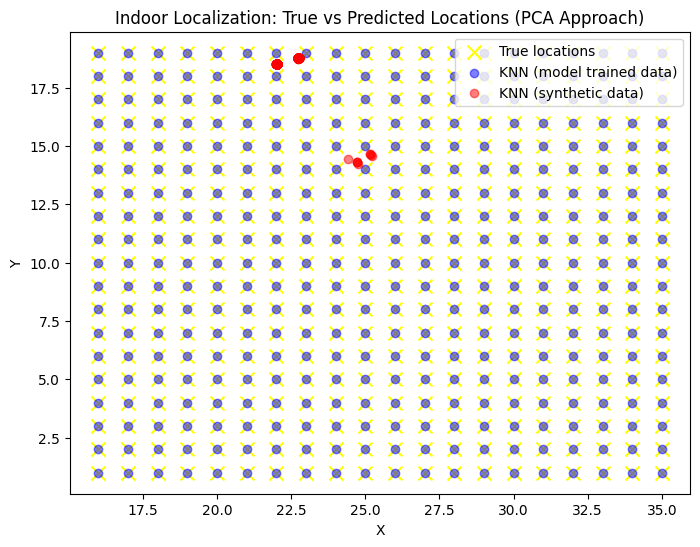

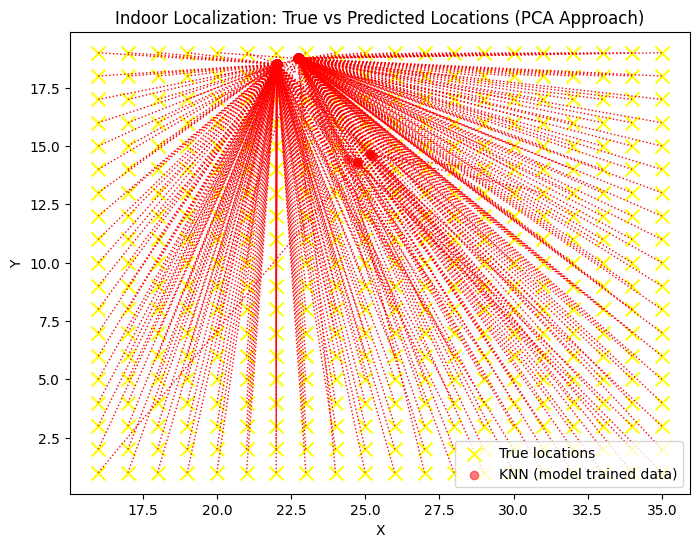

In [133]:
plot_indoor_localization_map(coordinate_data.values, pred_locations_real_data, pred_locations_synth_pca, "Indoor Localization: True vs Predicted Locations (PCA Approach)")
plot_indoor_localization_results(coordinate_data.values, pred_locations_synth_pca, "Indoor Localization: True vs Predicted Locations (PCA Approach)")

## Approach 4

Trying different aggregation methods

## Approach 5: Hyperparameter tuning (optuna)

In [40]:
%pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import optuna
from sklearn.model_selection import GridSearchCV

# Define a function to compute the Euclidean distance error.
def compute_localization_errors(true_locations, predicted_locations):
    errors = np.sqrt(np.sum((true_locations - predicted_locations) ** 2, axis=1))
    return errors


errors_list = []
mse_list = []

def objective(trial):
    # Suggest hyperparameters
    hidden_dim = trial.suggest_categorical('hidden_dim', [128, 256, 512, 1024, 2048])
    time_emb_dim = trial.suggest_categorical('time_emb_dim', [64, 128, 256, 512, 1024])
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-3)
    # dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.2, 0.3, 0,4, 0.5, 0.7)
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256, 512, 1024])
    diffusion_steps = trial.suggest_categorical('diffusion_steps', [20, 40, 60, 80, 100, 200])

    # --- Data Preparation for Diffusion Model Training (within Optuna trial) ---
    # Use the pre-aggregated and cleaned training data
    td_train_filled = ap_mean_by_xy.copy()
    # Fill NaN values in AP columns before scaling
    td_train_filled[ap_cols] = td_train_filled[ap_cols].fillna(-110)

    X_cond_np = td_train_filled[cond_cols].values.astype("float32")
    Y_rss_np = td_train_filled[ap_cols].values.astype("float32")

    rss_scaler = StandardScaler()
    Y_rss_scaled = rss_scaler.fit_transform(Y_rss_np)

    X_cond_t = torch.tensor(X_cond_np, dtype=torch.float32)
    y_rss_t = torch.tensor(Y_rss_scaled, dtype=torch.float32)

    rss_dim = y_rss_t.shape[1]
    cond_dim = X_cond_t.shape[1]

    # Instantiate and train the model
    # Use TableDiffusion class defined in the notebook
    model = TableDiffusion(rss_dim=rss_dim, cond_dim=cond_dim,
                           hidden=([hidden_dim, hidden_dim // 2, hidden_dim // 4] if hidden_dim == 512 else
                                   [hidden_dim, hidden_dim // 2] if hidden_dim == 256 else
                                   [hidden_dim]),  # Adjust hidden layers based on hidden_dim for TabularUNet
                           time_emb_dim=time_emb_dim)

    model = train_table_diffusion(
        model=model,
        X_cond=X_cond_t,
        Y_rss=y_rss_t,
        steps=diffusion_steps,
        batch_size=batch_size,
        epochs=400,  # Using epochs instead of n_epochs
        lr=learning_rate
    )

    # --- Evaluate model using the test set (df_test) ---
    # Assuming rss_cols refers to the list of AP columns, which is 'ap_cols' in this notebook
    rss_test_cols = ap_cols  # Use the globally defined ap_cols for RSS features

    # Prepare data from df_test for KNN evaluation
    # Fill NaN in df_test's RSS columns before splitting
    df_test_filled = df_test.copy()
    df_test_filled[rss_test_cols] = df_test_filled[rss_test_cols].fillna(-110)

    X_knn_all = df_test_filled[['X', 'Y']].values  # True locations
    rss_original_all = df_test_filled[rss_test_cols].values  # Original RSS fingerprints

    # 80-20 split for KNN evaluation (using the same random_state for consistency)
    X_knn_train, X_knn_test, rss_train_knn_input, rss_test_knn_input = train_test_split(
        X_knn_all, rss_original_all, test_size=0.2, random_state=42
    )

    # Generate a synthetic RSS dataset for the training set using the diffusion model.
    # We use the training locations (X_knn_train) as conditions.
    X_cond_for_generation = torch.tensor(X_knn_train, dtype=torch.float32)

    # Use the model trained in this trial and the scaler from this trial
    gen_rss_scaled = sample_table_diffusion(model, X_cond_for_generation, diffusion_steps=diffusion_steps)

    # Invert the scaling using the scaler from this trial's training
    synthetic_rss_train = rss_scaler.inverse_transform(gen_rss_scaled)

    # KNN trained on the synthetic RSS fingerprints generated from the diffusion model.

    knn = KNeighborsRegressor(
        weights='distance',  # closer fingerprints count more
        metric='euclidean'
    )
    param_grid = {'n_neighbors': range(1, 31)}
    # Create a GridSearchCV object
    grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    # Fit GridSearchCV to the training data
    grid_search.fit(synthetic_rss_train, X_knn_train)
    # Get the best parameters and best score
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best negative mean squared error: {grid_search.best_score_}")

    knn_synthetic = grid_search.best_estimator_

    # Predict locations for the KNN test input (original RSS from df_test)
    pred_locations_synthetic = knn_synthetic.predict(rss_test_knn_input)

    errors_synthetic = compute_localization_errors(X_knn_test, pred_locations_synthetic)
    mean_error_synthetic = np.mean(errors_synthetic)

    print("Mean Error (Synthetic Data): ", mean_error_synthetic)

    errors_list.append(errors_synthetic)
    mse_list.append(mean_error_synthetic)

    return mean_error_synthetic


# Define the study and optimize
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

# Output the best parameters
print("Best Hyperparameters: ", study.best_params)
print("Best Validation Loss: ", study.best_value)


[I 2025-11-13 16:48:53,024] A new study created in memory with name: no-name-d9ce27ee-6bf1-4053-bed3-04a7aaf83e8a
/var/folders/v9/7cj3jyks7yb4vjb3q1hjjly80000gn/T/ipykernel_35782/424160351.py:17: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-3)


Device: mps
[TableDiffusion] Epoch 1/400 - loss: 81.3840


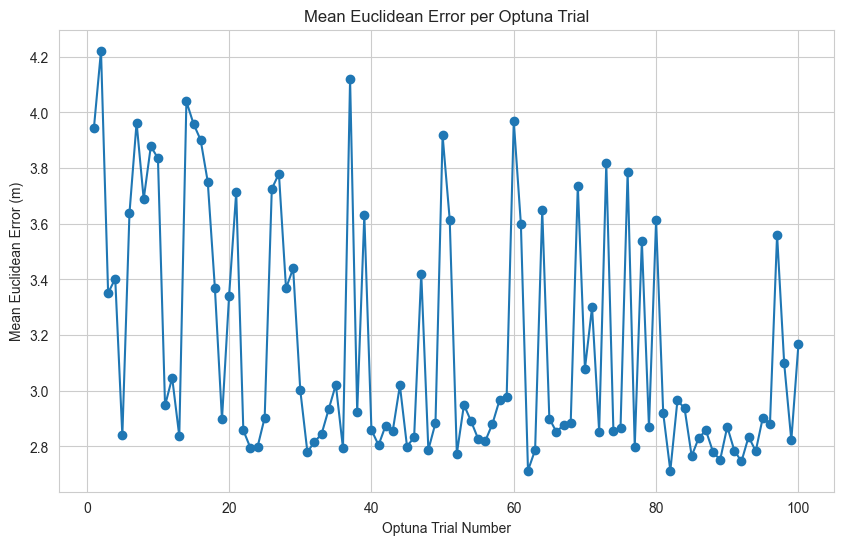

In [94]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(mse_list) + 1), mse_list, marker='o', linestyle='-')
plt.title('Mean Euclidean Error per Optuna Trial')
plt.xlabel('Optuna Trial Number')
plt.ylabel('Mean Euclidean Error (m)')
plt.grid(True)
plt.show()


In [95]:
min(mse_list)

2.7126559715210985